In [1]:
# import os

# def change_dir_in_hipergator():
#     # this env var is set on hipergator (SLURM is the job scheduler there)
#     if os.getenv("SLURM_JOB_ID", None):
#         target_dir = "diff_fam_social_memory_ephys"
#         current = os.getcwd()

#         while True:
#             parent = os.path.dirname(current)
#             # If we've reached the root directory without finding the target
#             if parent == current:
#                 raise FileNotFoundError(f"Could not find parent directory '{target_dir}'")

#             # Check if the target directory is the current parent's name
#             if os.path.basename(parent) == target_dir:
#                 os.chdir(parent)
#                 return parent

#             current = parent

# # Usage
# try:
#     new_path = change_dir_in_hipergator()
#     print(f"Successfully changed to directory: {new_path}")
# except FileNotFoundError as e:
#     print(e)

In [38]:
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
import os
from scipy.stats import sem
from matplotlib.lines import Line2D
import sys
import pickle
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.spike_collection as collection
import spike.spike_analysis.spike_recording as recording
import spike.spike_analysis.single_cell as single_cell
import spike.spike_analysis.population_analysis as population_analysis

import pickle
import seaborn as sns
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))




# Loading in the collection

In [3]:
cups_collection = collection.SpikeCollection.load_collection("pilot2/cups_phase4/cups_collection")
print(cups_collection)

SpikeCollection Summary:
  Number of Recordings: 8
  Total Good Units: 120
  Average Number of Good Units: 15.00
  Average Number of Events per Event Type: {'acquisition': 29.125, 'baseline': 110.5, 'blue_baseline': 25.0, 'blue_social': 13.25, 'cagemate': 32.0, 'cagemate_baseline': 25.5, 'cup 1': 23.5, 'cup 2': 25.375, 'cup 3': 32.0, 'cup 4': 29.625, 'empty': 12.375, 'empty acquisition': 63.25, 'familiar': 11.25, 'familiar_baseline': 25.75, 'green_baseline': 30.375, 'green_social': 19.25, 'novel': 19.375, 'novel_baseline': 30.25, 'orange_baseline': 25.125, 'orange_social': 16.375, 'pink_baseline': 30.0, 'pink_social': 26.125}
  
  Number of Unique Subjects: 8




In [4]:
behavior_dict = unpickle_this(r"pilot2/cups_phase4/cups_behavior_dicts_by_frame.pkl")
print(behavior_dict.keys())

dict_keys(['1.1', '1.3', '2.1', '2.2', '2.3', '2.4', '3.1', '3.2', '4.1', '4.4'])


In [5]:
for recording in cups_collection.recordings:
    print(recording.name)
    print(recording.subject)
    print(recording.event_dict['cagemate'][0])



11_cups_p4_merged.rec
1.1
[1931209.15 1939455.05]
13_cups_p4_merged.rec
1.3
[2065222.75 2072221.4 ]
21_cups_p4_merged.rec
2.1
[1885821.95 1886376.3 ]
22_cups_p4_merged.rec
2.2
[1974309.7 1975418.4]
24_cups_p4_merged.rec
2.4
[1884574.65 1884990.4 ]
32_cups_p4_merged.rec
3.2
[1898987.7 1902036.6]
41_cups_p4_merged.rec
4.1
[1886099.1 1886099.1]
44_cups_p4_merged.rec
4.4
[1938831.4  1949294.75]


In [6]:
cups_collection.analyze(timebin = 100, ignore_freq = 0.5, smoothing_window = 500)
events = ['cagemate', 'familiar', 'novel', 'empty']


All set to analyze


# PCA plots

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


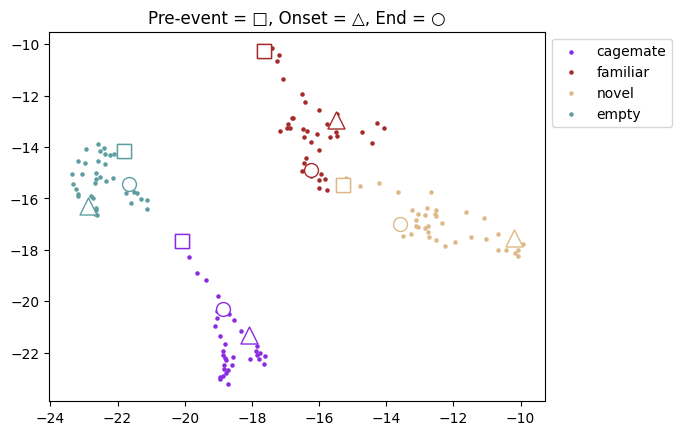

PCA Result with:
Events: cagemate, familiar, novel, empty
Timebins per event: 40.0
Total neurons: 109
Number of recordings: 8
Number of Pcs needed to explain 90% of variance 12


In [7]:
pca_result = population_analysis.avg_trajectories_pca(cups_collection, 3, 1, min_neurons = 5, events = events)
print(str(pca_result))

In [8]:
def plot_pca_results_3d(pca_result, title, colors, azim, elev, save = False):
    event_lengths = int(
            (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
        )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection="3d")
    #plt.subplots_adjust(left=0.3, right=0.99, bottom=0.1, top=0.9)
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        ax.plot3D(
            PCA_matrix[i : i + event_lengths, 0],
            PCA_matrix[i : i + event_lengths, 1],
            PCA_matrix[i : i + event_lengths, 2],
            label=event_label,
            color=colors[col_counter],
            linewidth = 5,
            alpha = 0.8
        )
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            PCA_matrix[i, 2],
            marker="s",
            s=100,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            PCA_matrix[onset, 2],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            PCA_matrix[end, 2],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
        )
        if post_window != 0:
            print("woo")
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                PCA_matrix[post, 2],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
            )
        col_counter += 1
    ax.legend(loc="upper left", bbox_to_anchor=(.9,1), frameon = False, fontsize = 14)
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    # ax.set_zlim(-20, 30)
    ax.view_init(azim = azim, elev =elev)
    ax.set_title(f"{title}", fontsize = 24, y = 1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi = 600, transparent = True,bbox_inches='tight' )
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        
        # Plot the continuous line with updated styling
        ax.plot(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            label=event_label,
            color=colors[col_counter],
            linewidth=5,
            alpha=0.8,
            zorder = 1
        )
        
        # Add markers with updated sizes
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            marker="s",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 2
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 3
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 4
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
                zorder =5
            )
        col_counter += 1
    
    # Updated legend formatting
    ax.legend(loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    
    # Updated title and label formatting
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add tight layout
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()

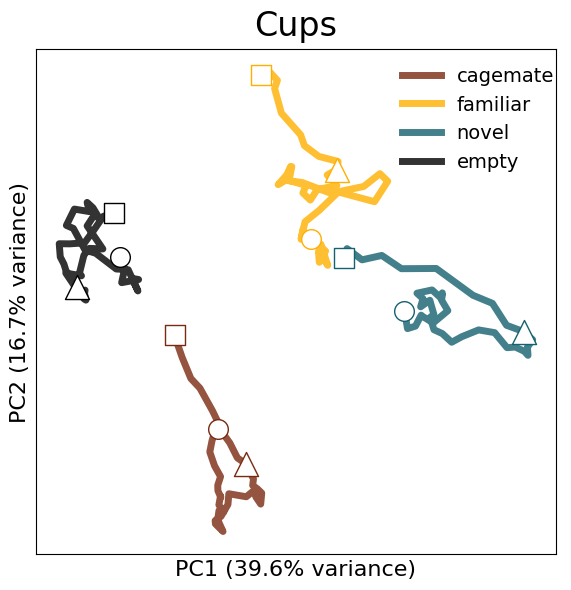

C:\Users\megha\AppData\Local\Temp\ipykernel_33980\3321336776.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


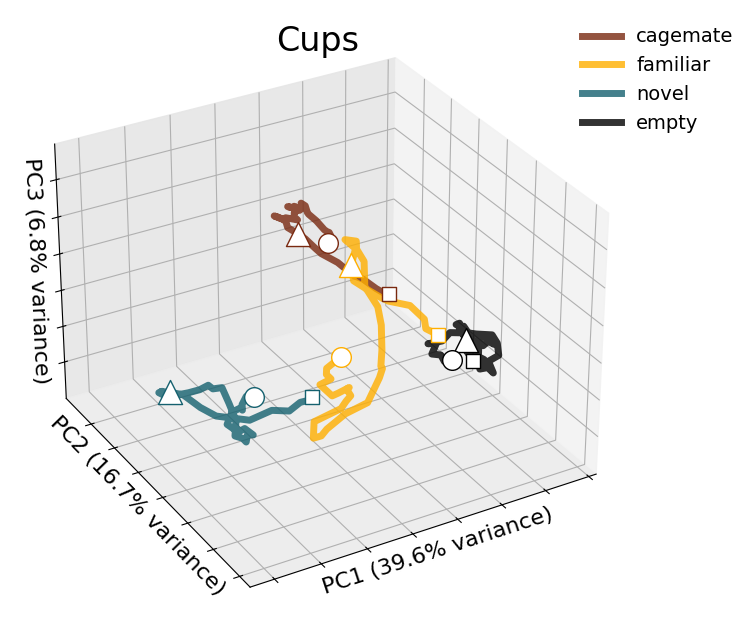

In [9]:
color_id_dict = {'novel': hex_2_rgb('#15616F'), 
                'familiar': (1.0, 0.6862745098039216, 0.0),
                  'cagemate': hex_2_rgb('#792910')}
plot_pca_results_2d(pca_result=pca_result, title = 'Cups', colors = [hex_2_rgb('#792910'),
                                                             (1.0, 0.6862745098039216, 0.0),
                                                             hex_2_rgb('#15616F'),
                                                             'black'], legend_spot = (0.67, 1))

plot_pca_results_3d(pca_result=pca_result, title = 'Cups', colors = [hex_2_rgb('#792910'),
                                                             (1.0, 0.6862745098039216, 0.0),
                                                             hex_2_rgb('#15616F'),
                                                             'black'], azim = 60, elev = 30)                

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


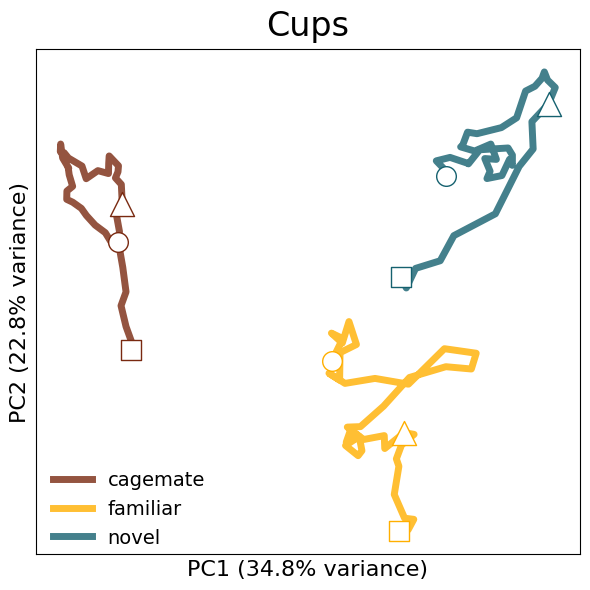

C:\Users\megha\AppData\Local\Temp\ipykernel_33980\3321336776.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


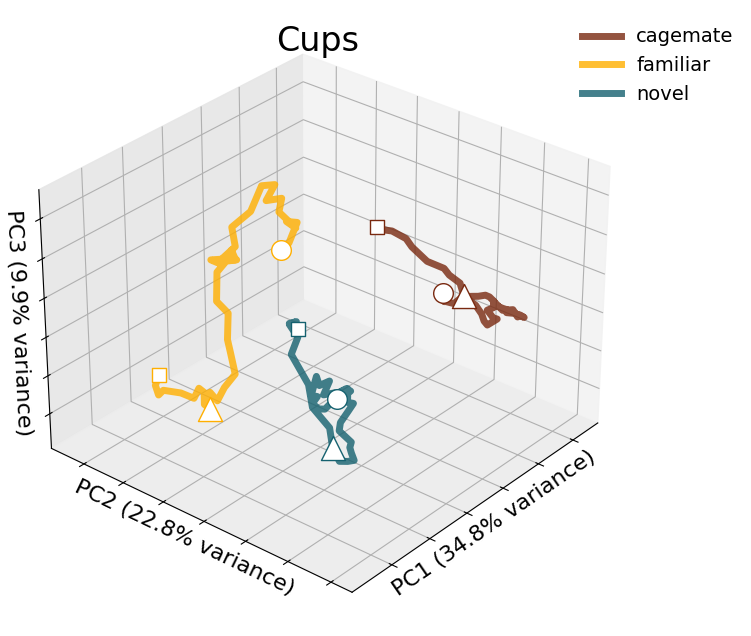

In [10]:
pca_result_no_empty = population_analysis.avg_trajectories_pca(cups_collection, event_length = 3, pre_window =1, post_window = 0, min_neurons = 5, events = ['cagemate','familiar','novel'], plot = False)

str(pca_result_no_empty)
plot_pca_results_2d(pca_result=pca_result_no_empty, title = 'Cups', colors = [hex_2_rgb('#792910'),
                                                             (1.0, 0.6862745098039216, 0.0),
                                                             hex_2_rgb('#15616F'),
                                                             'black'], legend_spot = (0, .2))

plot_pca_results_3d(pca_result=pca_result_no_empty, title = 'Cups', colors = [hex_2_rgb('#792910'),
                                                             (1.0, 0.6862745098039216, 0.0),
                                                             hex_2_rgb('#15616F'),
                                                             'black'], azim = 40, elev = 30)                


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


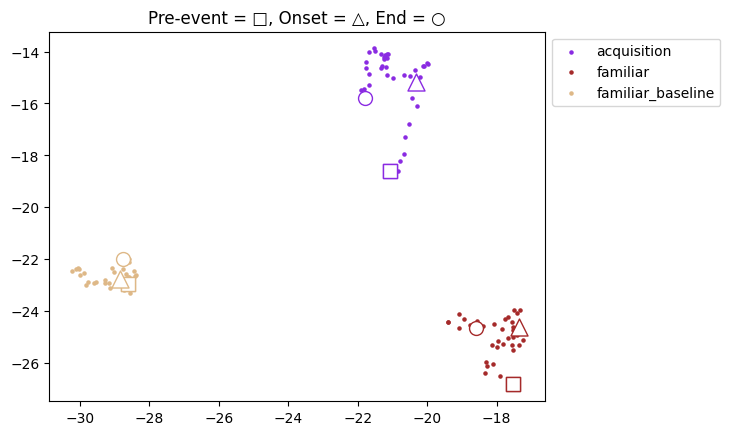

               Recording  Number of Neurons  Number of acquisition events  \
0  11_cups_p4_merged.rec                 21                            45   
1  41_cups_p4_merged.rec                 18                            30   
2  22_cups_p4_merged.rec                 16                            17   
3  21_cups_p4_merged.rec                 15                            18   
4  13_cups_p4_merged.rec                 12                            18   
5  24_cups_p4_merged.rec                 10                            56   
6  44_cups_p4_merged.rec                 10                            27   
7  32_cups_p4_merged.rec                  7                            22   

   Number of familiar events  Number of familiar_baseline events  
0                          3                                  33  
1                         25                                  31  
2                          6                                  28  
3                          9          

In [11]:
population_analysis.avg_trajectories_pca(cups_collection, events=['acquisition', 'familiar', 'familiar_baseline'], event_length=3, pre_window=1, post_window=0, min_neurons = 5)


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


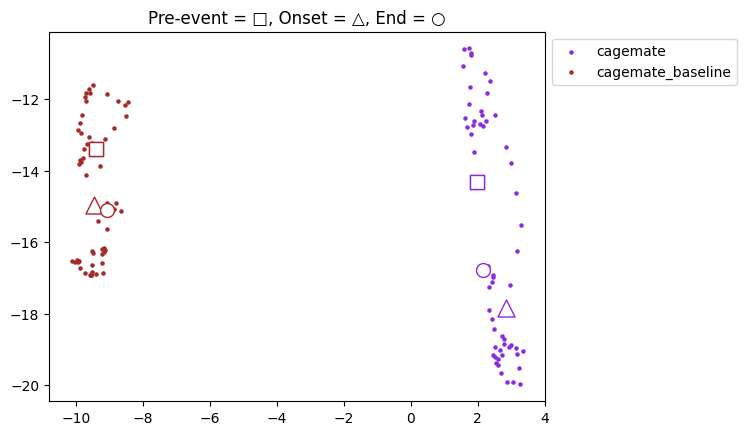

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


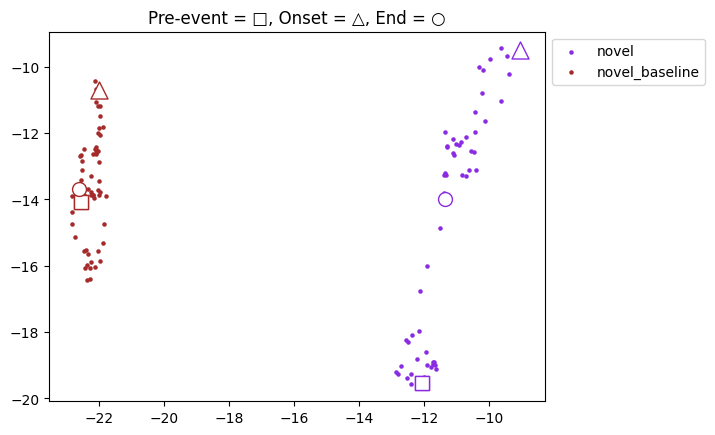

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


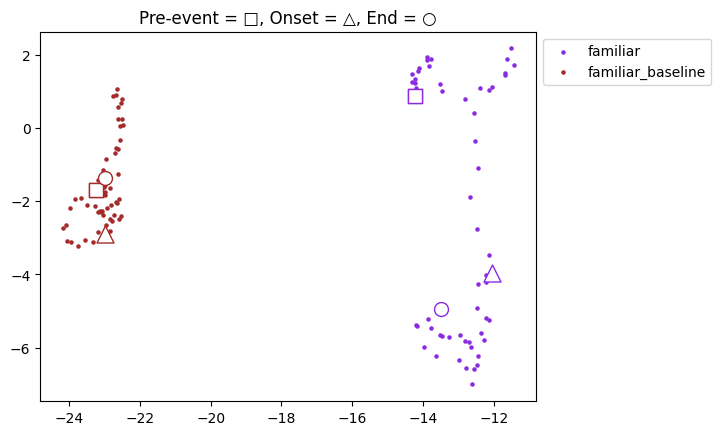

               Recording  Number of Neurons  Number of familiar events  \
0  11_cups_p4_merged.rec                 21                          3   
1  41_cups_p4_merged.rec                 18                         25   
2  22_cups_p4_merged.rec                 16                          6   
3  21_cups_p4_merged.rec                 15                          9   
4  13_cups_p4_merged.rec                 12                         11   
5  24_cups_p4_merged.rec                 10                         21   
6  44_cups_p4_merged.rec                 10                          5   
7  32_cups_p4_merged.rec                  7                          9   

   Number of familiar_baseline events  
0                                  33  
1                                  31  
2                                  28  
3                                  25  
4                                  17  
5                                  14  
6                                  42  
7            

In [12]:
population_analysis.avg_trajectories_pca(cups_collection, events=['cagemate', 'cagemate_baseline'], event_length=3, pre_window=3, post_window=0, min_neurons = 5)
population_analysis.avg_trajectories_pca(cups_collection, events=['novel', 'novel_baseline'], event_length=3, pre_window=3, post_window=0, min_neurons = 5)
population_analysis.avg_trajectories_pca(cups_collection, events=['familiar', 'familiar_baseline'], event_length=3, pre_window=3, post_window=0, min_neurons = 5)


## Geodesic distance plotting

In [13]:
novel_geo_dist = population_analysis.avg_geo_dist(cups_collection, events=events, event_length=3, pre_window=1, percent_var=90, post_window=0, min_neurons = 5)
novel_geo_dist
avg_vals_df = novel_geo_dist.mean()
avg_vals_df

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: U

cagemate_empty       211.381602
cagemate_familiar    191.517521
cagemate_novel       205.072046
empty_familiar       204.825599
empty_novel          226.191619
familiar_novel       234.143320
dtype: float64

In [14]:
def create_comparison_matrix(df):
    # Get unique experiments
    experiments = sorted(list(set([exp for col in df.columns for exp in col.split('_')])))
    n = len(experiments)
    
    # Create empty matrix
    matrix = np.zeros((n, n))
    
    # Fill matrix
    for i, exp1 in enumerate(experiments):
        for j, exp2 in enumerate(experiments):
            if i == j:
                matrix[i,j] = 1
            else:
                col1 = f"{exp1}_{exp2}"
                col2 = f"{exp2}_{exp1}"
                if col1 in df.columns:
                    matrix[i,j] = df[col1].mean()
                elif col2 in df.columns:
                    matrix[i,j] = df[col2].mean()
    
    return pd.DataFrame(matrix, index=experiments, columns=experiments)

def plot_comparison_heatmap(df, title):
    # Create comparison matrix
    matrix = create_comparison_matrix(df)
    
    # Create figure
    plt.figure(figsize=(5, 4))
    
    # Create heatmap
    sns.heatmap(matrix, 
                annot=True, 
                cmap='Blues',
                fmt='.3f',
                square=True,
                cbar_kws={'label': 'AU Distance'},
                vmin = 150)
    
    plt.title(title)
    plt.tight_layout()
    return plt

<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

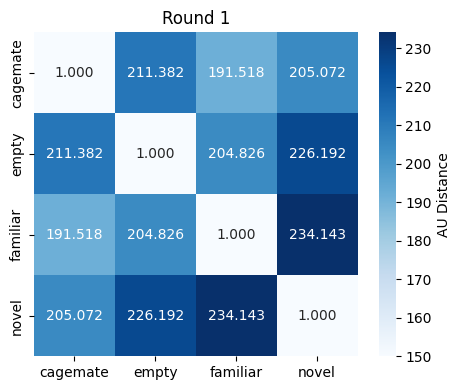

In [15]:
plot_comparison_heatmap(novel_geo_dist, title = 'Round 1')


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: U

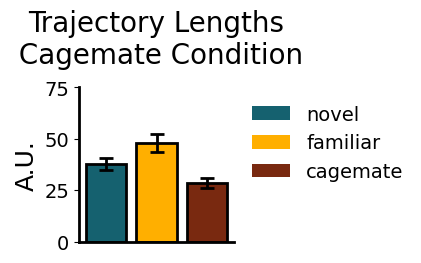

,Comparison,t_statistic,p_value,p_adjusted,significant
0,nov_fam,-2.460206,0.043452,0.086904,False
1,nov_cage,2.097454,0.074149,0.086904,False
2,fam_cage,3.567997,0.009121,0.027364,True


In [16]:
from scipy.spatial.distance import euclidean
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
import matplotlib.ticker as ticker
events = ['novel','familiar','cagemate']
def trajectory_length(pca_matrix, key):
    trajectory_lengths = []
    event_order = []
    unique_values, counts = np.unique(key, return_counts=True)
    event_len = counts[0]
    for j in range(0, len(key), event_len):
        trajectory_length = 0
        for i in range(event_len-1):
            trajectory_length = trajectory_length + euclidean(
                pca_matrix[j+i, :3],
                pca_matrix[j+i+1, :3])
        trajectory_lengths.append(trajectory_length)
        event_order.append(key[j])
    return [trajectory_lengths, event_order]

trajectory_lengths = []
orders= []
for recording in cups_collection.recordings:
    pc_dict = population_analysis.avg_trajectories_pca(recording, event_length = 5, pre_window = 3,
                                                 events = events, min_neurons=5, plot = False)
    if pc_dict:
        [traj_len, event_order] = trajectory_length(pc_dict.transformed_data,
                                                pc_dict.labels)
        trajectory_lengths.append(traj_len)
        orders.append(event_order)
trajectory_lengths = np.array(trajectory_lengths)



means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)

t_nov_fam, p_nov_fam = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,1])
t_nov_cage, p_nov_cage = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,2])
t_fam_cage, p_fam_cage = stats.ttest_rel(trajectory_lengths[:,1], trajectory_lengths[:,2])
p_values = [p_nov_fam, p_nov_cage, p_fam_cage]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['nov_fam', 'nov_cage', 'fam_cage'],
   't_statistic': [t_nov_fam, t_nov_cage, t_fam_cage],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

# Adjust p-values using Holm-Bonferroni
p_values = [p_nov_fam, p_nov_cage, p_fam_cage]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'novel': hex_2_rgb('#15616F'), 
                'familiar': (1.0, 0.6862745098039216, 0.0),
                  'cagemate': hex_2_rgb('#792910')}
hatches = ['','','']  
x = [0.5,1,1.5]
plt.figure(figsize= (2,2))           
plt.bar(x, means, yerr = sems,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(25))
plt.ylim(0,75)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Cagemate Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df


# Singel cell analysis

## presniff

In [79]:
event_lengths = [6, 5, 2, 5]
events = ['cagemate', 'novel' ,'familiar', 'acquisition']
presniff_window = 2
is_first = True
for i in range(len(events)):
    presniff1_df = single_cell.wilcoxon_collection(cups_collection,
                                             event = events[i],
                                             event_length = event_lengths[i], 
                                             baseline_window = presniff_window,
                                             plot = False)                                 
    if is_first:
        merged1_df = presniff1_df
        is_first = False
    else:
        suffix = f"_{events[i]}"
        merged1_df = pd.merge(merged1_df, presniff1_df,on=['Recording', 'Subject', 'original unit id'], suffixes=('', suffix))
    
base_columns = ['Subject', 'Recording', 'original unit id']
master1_df_presniff = merged1_df[base_columns].copy()
# Add comparison columns
for event in events:
   master1_df_presniff[f'{event} vs presniff'] = merged1_df[f'event1 vs event2_{event}' if event != 'cagemate' else 'event1 vs event2']

# Create trimmed version
master1_df_presniff_trimmed = master1_df_presniff[['original unit id'] + [f'{event} vs presniff' for event in events]]
def group_cells(exp1, exp3, exp4, exp5):
    group = ''
    if (exp1 == 'increases') or (exp1 == 'decreases'):
        group = 'cagemate'
    # if (exp2 == 'increases') or (exp2 == 'decreases'):
    #     group = group + 'exp2' 
    # if (exp3 == 'increases') or (exp3 == 'decreases'):
    #      group = group + 'acquisition'
    if (exp4 == 'increases') or (exp4 == 'decreases'):
        group = group + 'novel'
    if (exp5 == 'increases') or (exp5 == 'decreases'):
        group = group + 'familiar'
    return group

master1_df_presniff_trimmed['cell group'] = master1_df_presniff_trimmed.apply(lambda row: group_cells(row['cagemate vs presniff'],
                                                                  #row['exp2 vs presniff'],
                                                                  row['acquisition vs presniff'],
                                                                  row['novel vs presniff'],
                                                                  row['familiar vs presniff']), axis = 1)

                              

results1 = master1_df_presniff_trimmed.groupby('cell group').count()
results1      

Wilcoxon can't be done on 22_cups_p4_merged.rec novel, because <6 samples
Wilcoxon can't be done on 11_cups_p4_merged.rec familiar, because <6 samples
Wilcoxon can't be done on 44_cups_p4_merged.rec familiar, because <6 samples


C:\Users\megha\AppData\Local\Temp\ipykernel_33980\886320448.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master1_df_presniff_trimmed['cell group'] = master1_df_presniff_trimmed.apply(lambda row: group_cells(row['cagemate vs presniff'],


,original unit id,cagemate vs presniff,novel vs presniff,familiar vs presniff,acquisition vs presniff
cell group,,,,,
,40,40,40,40,40
cagemate,9,9,9,9,9
cagematefamiliar,2,2,2,2,2
cagematenovel,2,2,2,2,2
cagematenovelfamiliar,1,1,1,1,1
familiar,1,1,1,1,1
novel,5,5,5,5,5
novelfamiliar,2,2,2,2,2


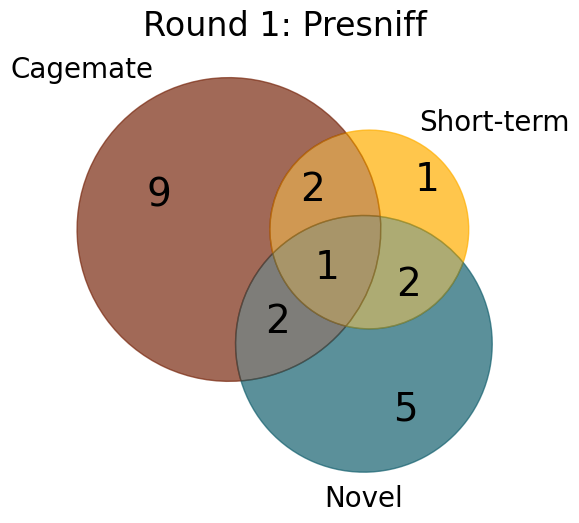

In [70]:
set1 = set(master1_df_presniff_trimmed.index[master1_df_presniff_trimmed['cell group'].str.contains('cagemate')])
set2 = set(master1_df_presniff_trimmed.index[master1_df_presniff_trimmed['cell group'].str.contains('familiar')])
set3 = set(master1_df_presniff_trimmed.index[master1_df_presniff_trimmed['cell group'].str.contains('novel')])
from matplotlib_venn import venn3

plt.figure(figsize=(8, 6))
venn = venn3([set1, set2, set3], ('Cagemate', 'Short-term', 'Novel'))
try:
   venn.get_patch_by_id('100').set_color('#792910') #exp 1 
   venn.get_patch_by_id('100').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('010').set_color('#FFAF00') #exp 4 
   venn.get_patch_by_id('010').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('001').set_color('#15616F') #exp 5 
   venn.get_patch_by_id('001').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('110').set_color('#bc6c08') # exp 1 + exp 4
   venn.get_patch_by_id('110').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('101').set_color('#474640') #exp1 + 5 
   venn.get_patch_by_id('101').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('011').set_color('#8a8838') # exp 4 and 5 
   venn.get_patch_by_id('011').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('111').set_color('#84682a') # all
   venn.get_patch_by_id('111').set_alpha(0.7)
except AttributeError:
   pass


    

for text in venn.set_labels:
    text.set_fontsize(20)  # Set label font size

for text in venn.subset_labels:
    if text:  # Check if the subset label exists
        text.set_fontsize(28) 
# Show the plot
plt.title('Round 1: Presniff', fontsize =24)
plt.show()

## Baseline


In [97]:
conditions    = ['cagemate', 'novel', 'familiar', 'acquisition']
event_lengths = [6, 5, 2, 5]
baselines     = ['baseline', 'baseline', 'baseline', 'baseline']
pre_window    = 2
post_window   = 0

is_first = True
for i in range(len(events)):
    presniff1_df = single_cell.wilcoxon_event1v2_collection(cups_collection,
                                             event1 = events[i],
                                             event2 = baselines[i],
                                             event_length = event_lengths[i],
                                             pre_window = 0,
                                             plot = False)
                                      
    if is_first:
        merged1_df = presniff1_df
        is_first = False
    else:
        suffix = f"_{events[i]}"
        merged1_df = pd.merge(merged1_df, presniff1_df,on=['Recording', 'Subject', 'original unit id'], suffixes=('', suffix))

base_columns = ['Subject', 'Recording', 'original unit id']
master1_df = merged1_df[base_columns].copy()

# Add comparison columns
for event in events:
   master1_df[f'{event} vs baseline'] = merged1_df[f'event1 vs event2_{event}' if event != 'cagemate' else 'event1 vs event2']
# Create trimmed version
master1_df_trimmed = master1_df[['original unit id'] + [f'{event} vs baseline' for event in events]]

master1_df_trimmed['cell group'] = master1_df_trimmed.apply(lambda row: group_cells(row['cagemate vs baseline'],
                                                                  #row['exp2 vs baseline'],
                                                                  row['acquisition vs baseline'],
                                                                  row['novel vs baseline'],
                                                                  row['familiar vs baseline']), axis = 1)



results1 = master1_df_trimmed.groupby('cell group').count()


Wilcoxon can't be done on 22_cups_p4_merged.rec because <6 samples for either novel or baseline
Wilcoxon can't be done on 11_cups_p4_merged.rec because <6 samples for either familiar or baseline
Wilcoxon can't be done on 44_cups_p4_merged.rec because <6 samples for either familiar or baseline


C:\Users\megha\AppData\Local\Temp\ipykernel_33980\720097848.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master1_df_trimmed['cell group'] = master1_df_trimmed.apply(lambda row: group_cells(row['cagemate vs baseline'],


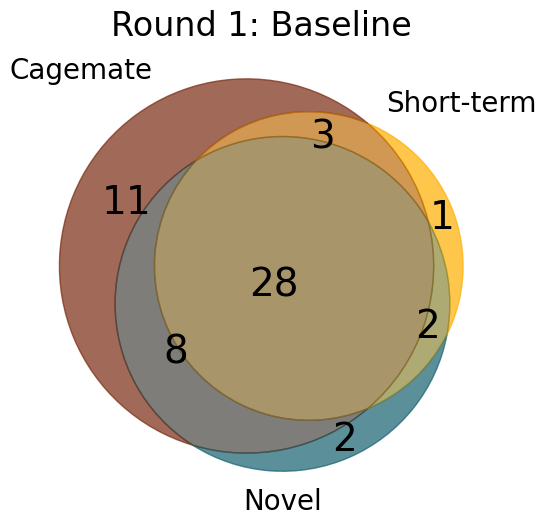

In [98]:
set1 = set(master1_df_trimmed.index[master1_df_trimmed['cell group'].str.contains('cagemate')])
set2 = set(master1_df_trimmed.index[master1_df_trimmed['cell group'].str.contains('familiar')])
set3 = set(master1_df_trimmed.index[master1_df_trimmed['cell group'].str.contains('novel')])
from matplotlib_venn import venn3

plt.figure(figsize=(8, 6))
venn = venn3([set1, set2, set3], ('Cagemate', 'Short-term', 'Novel'))
try:
   venn.get_patch_by_id('100').set_color('#792910') #exp 1 
   venn.get_patch_by_id('100').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('010').set_color('#FFAF00') #exp 4 
   venn.get_patch_by_id('010').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('001').set_color('#15616F') #exp 5 
   venn.get_patch_by_id('001').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('110').set_color('#bc6c08') # exp 1 + exp 4
   venn.get_patch_by_id('110').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('101').set_color('#474640') #exp1 + 5 
   venn.get_patch_by_id('101').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('011').set_color('#8a8838') # exp 4 and 5 
   venn.get_patch_by_id('011').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('111').set_color('#84682a') # all
   venn.get_patch_by_id('111').set_alpha(0.7)
except AttributeError:
   pass


    

for text in venn.set_labels:
    text.set_fontsize(20)  # Set label font size

for text in venn.subset_labels:
    if text:  # Check if the subset label exists
        text.set_fontsize(28) 
# Show the plot
plt.title('Round 1: Baseline', fontsize =24)
plt.show()

In [99]:

combined = pd.merge(master1_df_presniff, master1_df, on = ['Subject', 'Recording', 'original unit id'])
combined

,Subject,Recording,original unit id,cagemate vs presniff,novel vs presniff,familiar vs presniff,acquisition vs presniff,cagemate vs baseline,novel vs baseline,familiar vs baseline,acquisition vs baseline
0,1.3,13_cups_p4_merged.rec,13,not significant,not significant,not significant,not significant,increases,increases,increases,increases
1,1.3,13_cups_p4_merged.rec,17,not significant,not significant,not significant,not significant,increases,increases,increases,not significant
2,1.3,13_cups_p4_merged.rec,18,increases,not significant,not significant,increases,decreases,not significant,not significant,increases
3,1.3,13_cups_p4_merged.rec,20,not significant,increases,not significant,not significant,increases,increases,increases,increases
4,1.3,13_cups_p4_merged.rec,22,not significant,not significant,not significant,increases,decreases,decreases,not significant,decreases
...,...,...,...,...,...,...,...,...,...,...,...
57,4.1,41_cups_p4_merged.rec,25,not significant,not significant,not significant,not significant,decreases,not significant,not significant,not significant
58,4.1,41_cups_p4_merged.rec,26,increases,not significant,not significant,not significant,increases,increases,increases,increases
59,4.1,41_cups_p4_merged.rec,87,increases,not significant,not significant,not significant,increases,increases,increases,increases
60,4.1,41_cups_p4_merged.rec,88,not significant,increases,not significant,increases,increases,not significant,increases,not significant


In [100]:
import pandas as pd

conditions = ['cagemate', 'novel', 'familiar']

# significant = anything that is NOT 'not significant'
def is_sig(val):
    return val != 'not significant'

# boolean significance columns for convenience
for c in conditions:
    combined[f'{c}_sig_presniff']  = combined[f'{c} vs presniff'].apply(is_sig)
    combined[f'{c}_sig_baseline']  = combined[f'{c} vs baseline'].apply(is_sig)

# ============================================================
# PART 1
# For each condition x:
#   A) significant for x in BOTH presniff and baseline
#   B) significant for x in presniff only (not baseline)
#   C) significant for x in baseline only (not presniff)
#   D) significant for x in presniff (regardless of baseline) ← total presniff
#   E) significant for x in baseline (regardless of presniff) ← total baseline
# ============================================================

print("=" * 60)
print("PART 1: Per-condition overlap (presniff vs baseline)")
print("=" * 60)

part1 = {}
for c in conditions:
    ps  = combined[f'{c}_sig_presniff']
    bl  = combined[f'{c}_sig_baseline']

    both        = (ps & bl).sum()
    ps_only     = (ps & ~bl).sum()
    bl_only     = (~ps & bl).sum()
    total_ps    = ps.sum()
    total_bl    = bl.sum()
    n           = len(combined)

    part1[c] = {
        'n_neurons':               n,
        'sig_presniff_total':      total_ps,
        'sig_baseline_total':      total_bl,
        'sig_both':                both,
        'sig_presniff_only':       ps_only,
        'sig_baseline_only':       bl_only,
        'pct_both_of_presniff':    round(100 * both / total_ps,  1) if total_ps  > 0 else 0,
        'pct_both_of_baseline':    round(100 * both / total_bl,  1) if total_bl  > 0 else 0,
    }

    print(f"\n  {c.upper()}")
    print(f"    Total neurons:                    {n}")
    print(f"    Sig presniff (total):             {total_ps}  ({round(100*total_ps/n,1)}%)")
    print(f"    Sig baseline (total):             {total_bl}  ({round(100*total_bl/n,1)}%)")
    print(f"    Sig BOTH:                         {both}  ({round(100*both/n,1)}%)")
    print(f"    Sig presniff ONLY (not baseline): {ps_only}  ({round(100*ps_only/n,1)}%)")
    print(f"    Sig baseline ONLY (not presniff): {bl_only}  ({round(100*bl_only/n,1)}%)")

part1_df = pd.DataFrame(part1).T
print("\n--- Part 1 summary table ---")
print(part1_df)


# ============================================================
# PART 2
# Take neurons significant for baseline in ANY of the 3 conditions.
# Of those, what % are significant for:
#   - only cagemate presniff
#   - only novel presniff
#   - only familiar presniff
#   - none of the presniff conditions
#   - all 3 presniff conditions
#   - more than 1 presniff condition (but not all 3)
# ============================================================

print("\n" + "=" * 60)
print("PART 2: Presniff breakdown within baseline-significant neurons")
print("=" * 60)

# neurons significant in baseline for AT LEAST ONE condition
any_baseline_sig = (
    combined['cagemate_sig_baseline'] |
    combined['novel_sig_baseline']    |
    combined['familiar_sig_baseline']
)
baseline_pool = combined[any_baseline_sig].copy()
n_pool = len(baseline_pool)
print(f"\n  Neurons sig in baseline for ≥1 condition: {n_pool}")

# count how many presniff conditions each neuron is significant for
baseline_pool['n_presniff_sig'] = (
    baseline_pool['cagemate_sig_presniff'].astype(int) +
    baseline_pool['novel_sig_presniff'].astype(int)    +
    baseline_pool['familiar_sig_presniff'].astype(int)
)

def pct(n, total):
    return f"{n}  ({round(100*n/total, 1)}%)" if total > 0 else f"{n}  (N/A)"

# exclusive per condition
for c in conditions:
    others = [x for x in conditions if x != c]
    excl = (
         baseline_pool[f'{c}_sig_presniff'] &
        ~baseline_pool[f'{others[0]}_sig_presniff'] &
        ~baseline_pool[f'{others[1]}_sig_presniff']
    ).sum()
    print(f"    Only {c} presniff:  {pct(excl, n_pool)}")

# none
none_ps = (baseline_pool['n_presniff_sig'] == 0).sum()
print(f"    None presniff:     {pct(none_ps, n_pool)}")

# all 3
all3_ps = (baseline_pool['n_presniff_sig'] == 3).sum()
print(f"    All 3 presniff:    {pct(all3_ps, n_pool)}")

# more than 1 but not all 3
more1_ps = (baseline_pool['n_presniff_sig'] > 1).sum()
not_all  = more1_ps - all3_ps
print(f"    >1 presniff (not all 3): {pct(not_all, n_pool)}")

# sanity check — should sum to n_pool
check = (
    sum(
        (
             baseline_pool[f'{c}_sig_presniff'] &
            ~baseline_pool[[f'{x}_sig_presniff' for x in conditions if x != c][0]] &
            ~baseline_pool[[f'{x}_sig_presniff' for x in conditions if x != c][1]]
        ).sum()
        for c in conditions
    )
    + none_ps + all3_ps + not_all
)
print(f"\n  Sanity check (should = {n_pool}): {check}")

PART 1: Per-condition overlap (presniff vs baseline)

  CAGEMATE
    Total neurons:                    62
    Sig presniff (total):             14  (22.6%)
    Sig baseline (total):             50  (80.6%)
    Sig BOTH:                         13  (21.0%)
    Sig presniff ONLY (not baseline): 1  (1.6%)
    Sig baseline ONLY (not presniff): 37  (59.7%)

  NOVEL
    Total neurons:                    62
    Sig presniff (total):             10  (16.1%)
    Sig baseline (total):             40  (64.5%)
    Sig BOTH:                         6  (9.7%)
    Sig presniff ONLY (not baseline): 4  (6.5%)
    Sig baseline ONLY (not presniff): 34  (54.8%)

  FAMILIAR
    Total neurons:                    62
    Sig presniff (total):             6  (9.7%)
    Sig baseline (total):             34  (54.8%)
    Sig BOTH:                         3  (4.8%)
    Sig presniff ONLY (not baseline): 3  (4.8%)
    Sig baseline ONLY (not presniff): 31  (50.0%)

--- Part 1 summary table ---
          n_neurons  si

In [101]:
import pandas as pd

conditions = ['cagemate', 'novel', 'familiar']

# --- reuse your boolean sig columns from before ---
for c in conditions:
    combined[f'{c}_sig_presniff'] = combined[f'{c} vs presniff'] != 'not significant'
    combined[f'{c}_sig_baseline'] = combined[f'{c} vs baseline'] != 'not significant'

# convenience: number of baseline and presniff conditions each neuron is sig for
combined['n_baseline_sig'] = sum(combined[f'{c}_sig_baseline'] for c in conditions)
combined['n_presniff_sig'] = sum(combined[f'{c}_sig_presniff'] for c in conditions)

n_total = len(combined)

# ============================================================
# QUESTION 1
# Given a neuron is significant for ALL THREE conditions at baseline,
# what is the probability it is significant for EXACTLY ONE condition
# at presniff? And which one?
# ============================================================

print("=" * 60)
print("Q1: Given sig for ALL 3 at baseline → presniff breakdown")
print("=" * 60)

all3_baseline = combined[combined['n_baseline_sig'] == 3].copy()
n_all3_bl = len(all3_baseline)
print(f"\n  Neurons sig for all 3 at baseline: {n_all3_bl}")

if n_all3_bl > 0:
    # exactly one presniff condition
    exactly_one_ps = all3_baseline[all3_baseline['n_presniff_sig'] == 1]
    n_exactly_one  = len(exactly_one_ps)
    print(f"  Of those, sig for exactly 1 presniff condition: "
          f"{n_exactly_one} ({round(100 * n_exactly_one / n_all3_bl, 1)}%)")

    # which condition is that one?
    for c in conditions:
        only_this = (
            exactly_one_ps[f'{c}_sig_presniff'] &
           ~exactly_one_ps[[f'{x}_sig_presniff' for x in conditions if x != c][0]] &
           ~exactly_one_ps[[f'{x}_sig_presniff' for x in conditions if x != c][1]]
        ).sum()
        print(f"    → only {c} presniff: {only_this} "
              f"({round(100 * only_this / n_all3_bl, 1)}% of all3-baseline pool)")

    # full presniff breakdown for context
    print(f"\n  Full presniff breakdown within all3-baseline pool:")
    for k in range(4):
        n_k = (all3_baseline['n_presniff_sig'] == k).sum()
        print(f"    sig for {k} presniff conditions: {n_k} "
              f"({round(100 * n_k / n_all3_bl, 1)}%)")


# ============================================================
# QUESTION 2
# Given a neuron is significant for EXACTLY ONE condition at presniff,
#   a) what is P(sig for all 3 at baseline)?
#   b) what is P(sig for ONLY that same condition at baseline)?
# ============================================================

print("\n" + "=" * 60)
print("Q2: Given sig for exactly 1 condition at presniff → baseline breakdown")
print("=" * 60)

exactly_one_presniff = combined[combined['n_presniff_sig'] == 1].copy()
n_exactly_one_ps = len(exactly_one_presniff)
print(f"\n  Neurons sig for exactly 1 presniff condition: {n_exactly_one_ps}")

if n_exactly_one_ps > 0:

    # a) sig for all 3 at baseline
    all3_bl = (exactly_one_presniff['n_baseline_sig'] == 3).sum()
    print(f"\n  a) Sig for ALL 3 at baseline: "
          f"{all3_bl} ({round(100 * all3_bl / n_exactly_one_ps, 1)}%)")

    # b) for each condition: given neuron is sig for ONLY that condition
    #    at presniff, what fraction are sig for ONLY that condition at baseline?
    print(f"\n  b) Sig for ONLY that same condition at baseline:")
    for c in conditions:
        others = [x for x in conditions if x != c]

        # pool: sig for only THIS condition at presniff
        only_c_presniff = exactly_one_presniff[
             exactly_one_presniff[f'{c}_sig_presniff'] &
            ~exactly_one_presniff[f'{others[0]}_sig_presniff'] &
            ~exactly_one_presniff[f'{others[1]}_sig_presniff']
        ]
        n_only_c_ps = len(only_c_presniff)

        if n_only_c_ps == 0:
            print(f"    {c}: no neurons sig for only {c} at presniff")
            continue

        # of those, how many are sig for ONLY that condition at baseline too?
        only_c_baseline_too = (
             only_c_presniff[f'{c}_sig_baseline'] &
            ~only_c_presniff[f'{others[0]}_sig_baseline'] &
            ~only_c_presniff[f'{others[1]}_sig_baseline']
        ).sum()

        # and how many are sig for all 3 at baseline?
        all3_bl_given_c = (only_c_presniff['n_baseline_sig'] == 3).sum()

        print(f"\n    {c.upper()} (only {c} at presniff, n={n_only_c_ps}):")
        print(f"      → sig for only {c} at baseline:  "
              f"{only_c_baseline_too} ({round(100 * only_c_baseline_too / n_only_c_ps, 1)}%)")
        print(f"      → sig for all 3 at baseline:    "
              f"{all3_bl_given_c} ({round(100 * all3_bl_given_c / n_only_c_ps, 1)}%)")

        # full baseline breakdown for this sub-pool
        print(f"      Full baseline breakdown:")
        for k in range(4):
            n_k = (only_c_presniff['n_baseline_sig'] == k).sum()
            print(f"        sig for {k} baseline conditions: {n_k} "
                  f"({round(100 * n_k / n_only_c_ps, 1)}%)")

Q1: Given sig for ALL 3 at baseline → presniff breakdown

  Neurons sig for all 3 at baseline: 28
  Of those, sig for exactly 1 presniff condition: 6 (21.4%)
    → only cagemate presniff: 4 (14.3% of all3-baseline pool)
    → only novel presniff: 2 (7.1% of all3-baseline pool)
    → only familiar presniff: 0 (0.0% of all3-baseline pool)

  Full presniff breakdown within all3-baseline pool:
    sig for 0 presniff conditions: 20 (71.4%)
    sig for 1 presniff conditions: 6 (21.4%)
    sig for 2 presniff conditions: 1 (3.6%)
    sig for 3 presniff conditions: 1 (3.6%)

Q2: Given sig for exactly 1 condition at presniff → baseline breakdown

  Neurons sig for exactly 1 presniff condition: 15

  a) Sig for ALL 3 at baseline: 6 (40.0%)

  b) Sig for ONLY that same condition at baseline:

    CAGEMATE (only cagemate at presniff, n=9):
      → sig for only cagemate at baseline:  3 (33.3%)
      → sig for all 3 at baseline:    4 (44.4%)
      Full baseline breakdown:
        sig for 0 baseline c

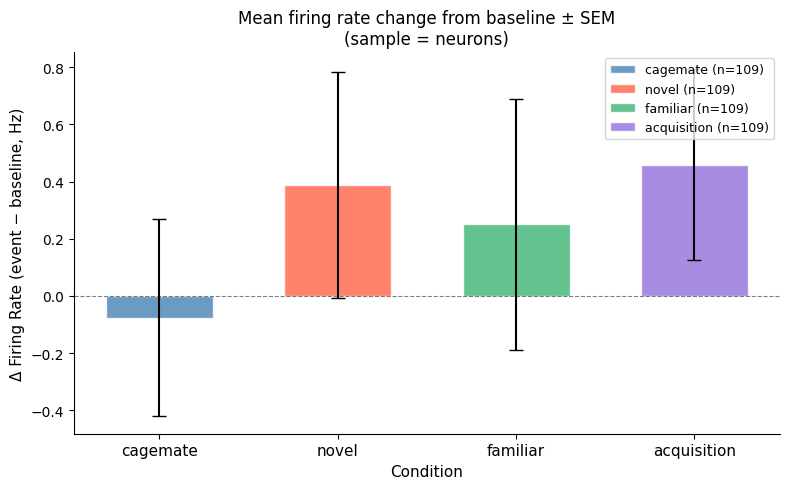

Condition        n neurons    mean Δ FR        SEM
--------------------------------------------------
cagemate               109      -0.0759     0.3454
novel                  109       0.3880     0.3963
familiar               109       0.2506     0.4389
acquisition            109       0.4583     0.3337


In [91]:
event_lengths = [6, 5, 2, 5]
events = ['cagemate', 'novel' ,'familiar', 'acquisition']
baselines = ['cagemate_baseline', 'novel_baseline', 'familiar_baseline', 'familiar_baseline']
baseline_window = 2

avg_firing_rates = {event: [] for event in events}
for recording in cups_collection.recordings:
    for i in range(len(events)):
        # [trial, timebins, units]
        event_snippets = recording.event_firing_rates(event = events[i], event_length = event_lengths[i], pre_window = 2, post_window = 0)
        event_average_firing_rates = np.nanmean(np.nanmean(event_snippets, axis = 0), axis = 1) #one trial averaged event, and then one average per event 
        baseline_snippets = recording.event_firing_rates(event = baselines[i], event_length = event_lengths[i], pre_window = 2, post_window = 0)
        baseline_average_firing_rates = np.nanmean(np.nanmean(baseline_snippets, axis = 0), axis = 1) #one trial averaged baseline, and then one average per baseline

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

conditions    = ['cagemate', 'novel', 'familiar', 'acquisition']
event_lengths = [6, 5, 2, 5]
baselines     = ['cagemate_baseline', 'novel_baseline', 'familiar_baseline', 'familiar_baseline']
pre_window    = 2
post_window   = 0

diff_per_event = {event: [] for event in conditions}

for recording in cups_collection.recordings:
    for i, event in enumerate(conditions):

        event_snippets = recording.event_firing_rates(
            event=event,
            event_length=event_lengths[i],
            pre_window=pre_window,
            post_window=post_window
        )  # shape: (trials, timebins, units)

        baseline_snippets = recording.event_firing_rates(
            event=baselines[i],
            event_length=event_lengths[i],
            pre_window=pre_window,
            post_window=post_window
        )  # shape: (trials, timebins, units)

        if event_snippets is None or baseline_snippets is None:
            continue
        if event_snippets.size == 0 or baseline_snippets.size == 0:
            continue

        # average across trials → (timebins, units)
        event_avg    = np.nanmean(event_snippets,    axis=0)
        baseline_avg = np.nanmean(baseline_snippets, axis=0)

        # difference at each timebin → (timebins, units)
        diff_timebins = event_avg - baseline_avg

        # average across timebins → (units,)  ← one value per neuron
        diff_per_neuron = np.nanmean(diff_timebins, axis=0)

        diff_per_event[event].append(diff_per_neuron)

# concatenate across recordings → one array per event, sample = neurons
for event in conditions:
    if diff_per_event[event]:
        diff_per_event[event] = np.concatenate(diff_per_event[event])
    else:
        diff_per_event[event] = np.array([])

# --- plot ---
color_map = {
    'cagemate':    'steelblue',
    'novel':       'tomato',
    'familiar':    'mediumseagreen',
    'acquisition': 'mediumpurple',
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, event in enumerate(conditions):
    data = diff_per_event[event]
    if len(data) == 0:
        continue

    mean = np.nanmean(data)
    sem  = stats.sem(data, nan_policy='omit')
    n    = np.sum(~np.isnan(data))

    ax.bar(i, mean, width=0.6, color=color_map[event],
           alpha=0.8, label=f'{event} (n={n})', edgecolor='white')
    ax.errorbar(i, mean, yerr=sem, fmt='none',
                color='black', capsize=5, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(np.arange(len(conditions)))
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel('Δ Firing Rate (event − baseline, Hz)', fontsize=11)
ax.set_xlabel('Condition', fontsize=11)
ax.set_title('Mean firing rate change from baseline ± SEM\n(sample = neurons)', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# --- summary table ---
print(f"{'Condition':<15} {'n neurons':>10} {'mean Δ FR':>12} {'SEM':>10}")
print("-" * 50)
for event in conditions:
    data = diff_per_event[event]
    if len(data) == 0:
        print(f"{event:<15} {'no data':>10}")
        continue
    n    = np.sum(~np.isnan(data))
    mean = np.nanmean(data)
    sem  = stats.sem(data, nan_policy='omit')
    print(f"{event:<15} {n:>10} {mean:>12.4f} {sem:>10.4f}")

Neurons passing filter (sig all 3 baseline):
  cagemate: n = 28
  novel: n = 28
  familiar: n = 28
  acquisition: n = 28


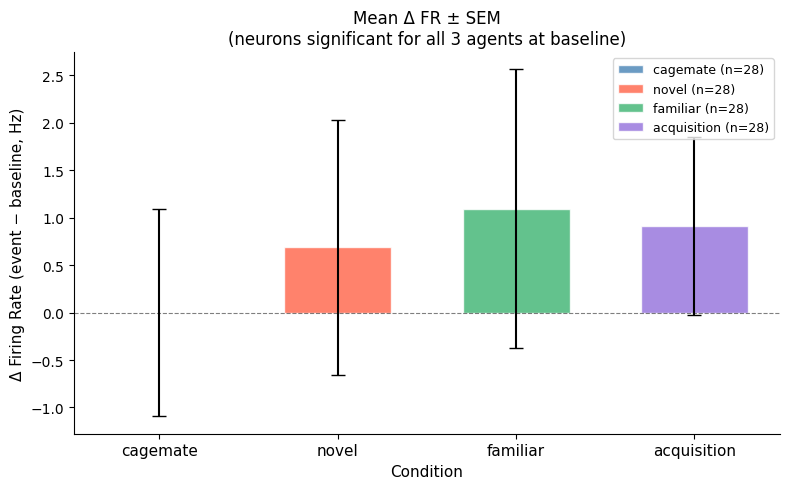


Condition        n neurons    mean Δ FR        SEM
--------------------------------------------------
cagemate                28       0.0002     1.0939
novel                   28       0.6871     1.3405
familiar                28       1.0944     1.4686
acquisition             28       0.9118     0.9373


In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def to_trial_array(x):
    """normalize whatever unit_event_firing_rates returns to (trials, timebins)"""
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        if x.ndim == 1:
            return x[np.newaxis, :]   # (1, timebins)
        return x                       # already (trials, timebins)
    if isinstance(x, list):
        if len(x) == 0:
            return None
        return np.vstack(x)            # list of 1D arrays → (trials, timebins)
    return None

conditions    = ['cagemate', 'novel', 'familiar', 'acquisition']
event_lengths = [6, 5, 2, 5]
baselines     = ['baseline', 'baseline', 'baseline', 'baseline']
pre_window    = 2
post_window   = 0

# conditions we check for baseline significance (exclude acquisition)
sig_conditions = ['cagemate', 'novel', 'familiar']

# --- build a lookup: (Subject, Recording) → set of unit ids sig for all 3 baseline ---
# reuse your boolean columns from earlier
for c in sig_conditions:
    combined[f'{c}_sig_baseline'] = combined[f'{c} vs baseline'] != 'not significant'

combined['n_baseline_sig'] = sum(
    combined[f'{c}_sig_baseline'] for c in sig_conditions
)

# neurons significant for ALL 3 baseline conditions
all3_df = combined[combined['n_baseline_sig'] == 3]

# build lookup dict: (Subject, Recording) → set of unit ids
sig_units_lookup = (
    all3_df
    .groupby(['Subject', 'Recording'])['original unit id']
    .apply(set)
    .to_dict()
)

# ---------------------------------------------------------------
diff_per_event = {event: [] for event in conditions}

for recording in cups_collection.recordings:

    # get the set of sig-all3-baseline units for this recording
    key = (recording.subject, recording.name)  # adjust attribute names if needed
    sig_units = sig_units_lookup.get(key, set())

    if len(sig_units) == 0:
        continue  # no qualifying neurons in this recording

    for i, event in enumerate(conditions):

        # --- get per-unit firing rates ---
        # unit_event_frs: dict  {unit_id: list of arrays, one array per event instance}
        # each array shape: (timebins,)  — one trial at a time
        unit_event_frs    = recording.unit_event_firing_rates(
            event=event,
            event_length=event_lengths[i],
            pre_window=pre_window,
            post_window=post_window,
        )
        unit_baseline_frs = recording.unit_event_firing_rates(
            event=baselines[i],
            event_length=event_lengths[i],
            pre_window=pre_window,
            post_window=post_window,
        )

        if unit_event_frs is None or unit_baseline_frs is None:
            continue

        # --- filter to sig-all3-baseline units only ---
        units_to_use = [
            u for u in unit_event_frs.keys()
            if u in sig_units and u in unit_baseline_frs
        ]

        if len(units_to_use) == 0:
            continue

        for unit in units_to_use:
            event_arr    = to_trial_array(unit_event_frs[unit])
            baseline_arr = to_trial_array(unit_baseline_frs[unit])

            if event_arr is None or baseline_arr is None:
                continue
            if event_arr.size == 0 or baseline_arr.size == 0:
                continue

            # average across trials (axis=0) → (timebins,)
            event_avg    = np.nanmean(event_arr,    axis=0)
            baseline_avg = np.nanmean(baseline_arr, axis=0)

            # difference per timebin → (timebins,)
            diff_timebins = event_avg - baseline_avg

            # average across timebins → scalar
            diff_per_neuron = np.nanmean(diff_timebins)

            diff_per_event[event].append(diff_per_neuron)

# convert lists to arrays
for event in conditions:
    diff_per_event[event] = np.array(diff_per_event[event]) if diff_per_event[event] else np.array([])

# --- print how many neurons made it into each condition ---
print("Neurons passing filter (sig all 3 baseline):")
for event in conditions:
    print(f"  {event}: n = {len(diff_per_event[event])}")

# --- plot ---
color_map = {
    'cagemate':    'steelblue',
    'novel':       'tomato',
    'familiar':    'mediumseagreen',
    'acquisition': 'mediumpurple',
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, event in enumerate(conditions):
    data = diff_per_event[event]
    if len(data) == 0:
        print(f"  Warning: no data for {event}, skipping")
        continue

    mean = np.nanmean(data)
    sem  = stats.sem(data, nan_policy='omit')
    n    = np.sum(~np.isnan(data))

    ax.bar(i, mean, width=0.6, color=color_map[event],
           alpha=0.8, label=f'{event} (n={n})', edgecolor='white')
    ax.errorbar(i, mean, yerr=sem, fmt='none',
                color='black', capsize=5, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(np.arange(len(conditions)))
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel('Δ Firing Rate (event − baseline, Hz)', fontsize=11)
ax.set_xlabel('Condition', fontsize=11)
ax.set_title(
    'Mean Δ FR ± SEM\n(neurons significant for all 3 agents at baseline)',
    fontsize=12
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- summary table ---
print(f"\n{'Condition':<15} {'n neurons':>10} {'mean Δ FR':>12} {'SEM':>10}")
print("-" * 50)
for event in conditions:
    data = diff_per_event[event]
    if len(data) == 0:
        print(f"{event:<15} {'no data':>10}")
        continue
    n    = np.sum(~np.isnan(data))
    mean = np.nanmean(data)
    sem  = stats.sem(data, nan_policy='omit')
    print(f"{event:<15} {n:>10} {mean:>12.4f} {sem:>10.4f}")

## Bootstrapping

In [21]:

# bootstrap_results = single_cell.bootstrap(cups_collection, ['cagemate', 'familiar', 'novel'], 3, pre_window = 0, num_perm = 2000)
# bootstrap_results.to_csv('pilot2/cups_phase4/output/bootstrap_results.csv')
bootstrap_results = pd.read_csv('pilot2/cups_phase4/output/bootstrap_results.csv')


In [22]:

def group_cells(exp1, exp4, exp5):
    group = ''
    if (exp1 == 'significantly increased') or (exp1 == 'significantly decreased'):
        group = 'cagemate'
    # if (exp2 == 'increases') or (exp2 == 'decreases'):
    #     group = group + 'exp2' 
    # if (exp3 == 'increases') or (exp3 == 'decreases'):
    #     group = group + 'exp3'
    if (exp4 == 'significantly increased') or (exp4 == 'significantly decreased'):
        group = group + 'familiar'
    if (exp5 == 'significantly increased') or (exp5 == 'significantly decreased'):
        group = group + 'novel'
    return group

bootstrap_results['cell group'] = bootstrap_results.apply(lambda row: group_cells(row['cagemate'],
                                                                  #row['exp2 vs baseline'],
                                                                  #row['exp3 vs baseline'],
                                                                  row['familiar'],
                                                                  row['novel']), axis = 1)


results = bootstrap_results.groupby('cell group').count()


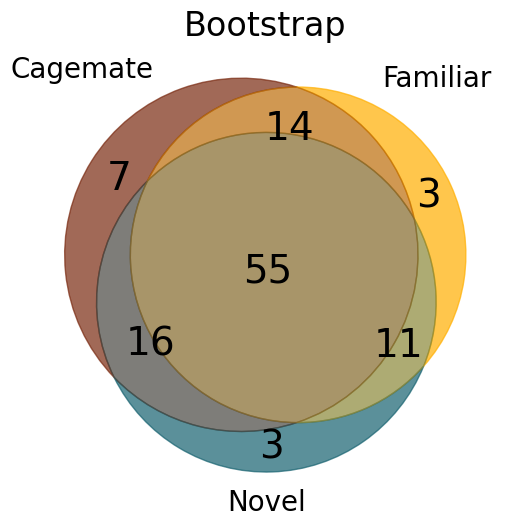

In [23]:
set1 = set(bootstrap_results.index[bootstrap_results['cell group'].str.contains('cagemate')])
set2 = set(bootstrap_results.index[bootstrap_results['cell group'].str.contains('familiar')])
set3 = set(bootstrap_results.index[bootstrap_results['cell group'].str.contains('novel')])
from matplotlib_venn import venn3

plt.figure(figsize=(8, 6))
venn = venn3([set1, set2, set3], ('Cagemate', 'Familiar', 'Novel'))
try:
   venn.get_patch_by_id('100').set_color('#792910') #exp 1 
   venn.get_patch_by_id('100').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('010').set_color('#FFAF00') #exp 4 
   venn.get_patch_by_id('010').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('001').set_color('#15616F') #exp 5 
   venn.get_patch_by_id('001').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('110').set_color('#bc6c08') # exp 1 + exp 4
   venn.get_patch_by_id('110').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('101').set_color('#474640') #exp1 + 5 
   venn.get_patch_by_id('101').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('011').set_color('#8a8838') # exp 4 and 5 
   venn.get_patch_by_id('011').set_alpha(0.7)
except AttributeError:
   pass

try:
   venn.get_patch_by_id('111').set_color('#84682a') # all
   venn.get_patch_by_id('111').set_alpha(0.7)
except AttributeError:
   pass



    

for text in venn.set_labels:
    text.set_fontsize(20)  # Set label font size

for text in venn.subset_labels:
    if text:  # Check if the subset label exists
        text.set_fontsize(28) 
# Show the plot
plt.title('Bootstrap', fontsize =24)
plt.show()

In [24]:
values = []
meaning = []
for exposure in ['cagemate', 'familiar']:
    for conditionA in ["significantly increased", "significantly decreased", "not significantly changed"]:
        temp = bootstrap_results[bootstrap_results[exposure] == conditionA]
        for conditionB in ["significantly increased", "significantly decreased", "not significantly changed"]:
            if exposure == 'cagemate':
                values.append(int(temp['familiar'].value_counts()[conditionB]))
                meaning.append(exposure + conditionA + 'exp4' + conditionB) 
            if exposure == 'familiar':
                values.append(temp['novel'].value_counts()[conditionB])
                meaning.append(exposure + conditionA + 'novel' + conditionB) 

In [25]:
import plotly.graph_objects as go
names = ["significantly increased", "significantly decreased", "no change",           # First stage
                "significantly increased", "significantly decreased", "no change",  
                " significantly increased", " significantly decreased", " no change"]
targets = ["significantly increased", "significantly decreased", "no change",           # First stage
                "significantly increased", "significantly decreased", "no change",  
                " significantly increased", " significantly decreased", " no change",
                "significantly increased", "significantly decreased", "no change",           # First stage
                "significantly increased", "significantly decreased", "no change",  
                " significantly increased", " significantly decreased", " no change"]
color_dict = {'increased':'red','decreased':'blue','change':'grey'}
color_dict_links = {"increased":"#FFDCDC", 'decreased': "#DCE5FF", 'change':  "#DBDBDB"}
fig = go.Figure(data=[go.Sankey(
    node = dict(
        label = names,             # Third stage
        pad = 15,
        thickness = 20,
        color = [color_dict[x.split(' ')[-1]] for x in names],
         y = [0.15, 0.49, 0.85,     # First stage (A_1, B_1, C_1)
            0.18, 0.51, 0.84,     # Second stage (A_2, B_2, C_2) 
            0.18, 0.55, 0.88],    # Third stage (A_3, B_3, C_3)
       # x positions to space out stages
        x = [0.1, 0.1, 0.1,       # First stage
            0.5, 0.5, 0.5,       # Second stage
            0.9, 0.9, 0.9] 
    ),
    link = dict(
        # First stage to second stage
        source = [0, 0, 0,          # Math101 to Pass/Fail
                 1, 1, 1,
                 2, 2, 2,
                 3, 3, 3, 
                 4, 4, 4, 
                 5, 5, 5],          # Physics101 to Pass/Fail
        target = [3, 4, 5,          # to Pass Math/Fail Math
                 3, 4, 5,
                 3, 4, 5,
                 6, 7, 8,
                 6, 7, 8,
                 6, 7, 8],          # to Pass Physics/Fail Physics
        value = values,  
        color = [color_dict_links[x.split(' ')[-1]] for x in targets],
         
      
               # 70 pass physics, 30 fail
    )
)])
fig.update_layout(
    annotations=[
        # First group title
        dict(
            x=-0.05,  # x position (0 to 1)
            y=1.1,  # y position above the plot
            xref="paper",
            yref="paper",
            text="Cagemate",
            showarrow=False,
            font=dict(size=16)
        ),
        # Second group title
        dict(
            x=0.5,
            y=1.1,
            xref="paper",
            yref="paper",
            text="Familiar",
            showarrow=False,
            font=dict(size=16)
        ),
        # Third group title
        dict(
            x=1.05,
            y=1.1,
            xref="paper",
            yref="paper",
            text="Novel",
            showarrow=False,
            font=dict(size=16)
        ),
        # dict(
        #     x=.5,
        #     y=1.3,
        #     xref="paper",
        #     yref="paper",
        #     text="Novel",
        #     showarrow=False,
        #     font=dict(size=24)
        # )
    ],
    # Add more top margin to make room for labels
    margin=dict(t=100)
)

fig.show()

In [26]:
print(values)


[24, 5, 8, 11, 29, 15, 6, 8, 3, 27, 6, 8, 9, 24, 9, 9, 10, 7]


# Decoders

## Agent Decoders

In [55]:
import spike.spike_analysis.decoders as decoders

pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
events = ['cagemate','novel','familiar']

agent_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5)      
                                         
                                    


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [103]:
from importlib import reload
reload(decoders)
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
events = ['cagemate','novel','familiar']

agent_decoder_results_CCGP = decoders.trial_decoder_cross_generalization(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5)   

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [104]:
agent_decoder_results_CCGP_linear = decoders.trial_decoder_cross_generalization(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         classifier_type='linear',
                                         min_neurons = 5)   

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [107]:
%matplotlib inline

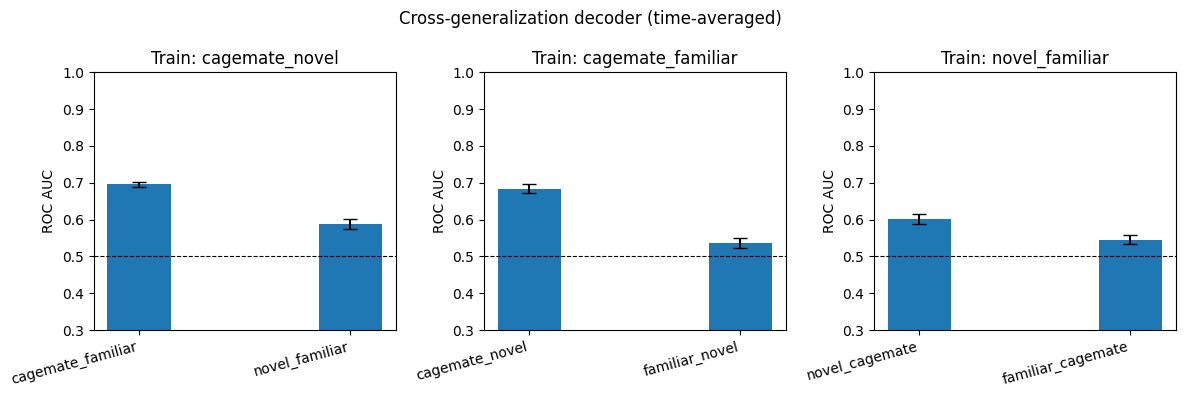

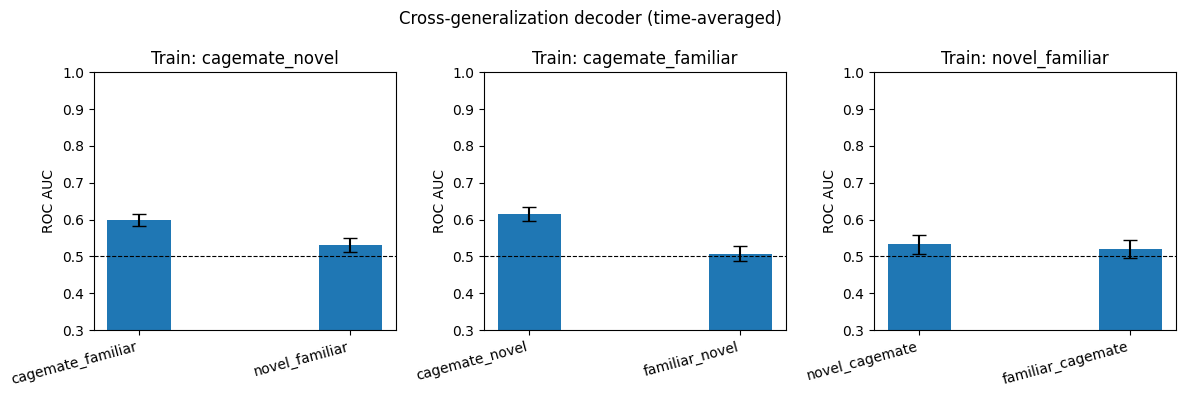

In [109]:
agent_decoder_results_CCGP.plot_average()
agent_decoder_results_CCGP_linear.plot_average()

In [ ]:
from matplotlib.patches import Patch
def plot_decoder_results(decoder, title, color_list, legend_titles, figsize, start=0, stop=None, ):
    bar_width = 0.2
    plt.figure(figsize=figsize)
    
    bar_position = 0  # Starting position for bars
    bar_centers = []  # Store center positions for labels
    j = 0
    
    # First, create bars without labels
    for key, results in decoder.results.items():
        
        total_event = decoder.event_length + decoder.post_window
        x = np.linspace(-decoder.pre_window, total_event, np.array(results.roc_auc).shape[0])
        
        if start is not None:
            plot_start = np.where(x >= start)[0][0]
        if stop is None:
            plot_stop = results.roc_auc.shape[0]
        if stop is not None:
            plot_stop = np.where(x <= stop)[0][-1] + 1
            
        rf_avg = np.mean(np.mean(results.roc_auc[start:stop], axis=0), axis=0)
        rf_sem = sem(np.mean(results.roc_auc[plot_start:plot_stop], axis=0))
        rf_shuffle_avg = np.mean(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0), axis=0)
        rf_shuffle_sem = sem(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0))
        
        # Plot bars without labels
        plt.bar(bar_position, rf_avg, bar_width, 
               yerr=rf_sem, capsize=5, color=color_list[j], 
               edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        plt.bar(bar_position + bar_width, rf_shuffle_avg, bar_width, 
               yerr=rf_shuffle_sem, capsize=5, color=color_list[j], 
               hatch='//', edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        
        # Store center position for this pair of bars
        bar_centers.append(bar_position + bar_width/2)
        
        bar_position += 0.6
        j += 1
    
    # Add centered labels under each pair of bars
    plt.xticks(bar_centers, legend_titles, fontsize=12)
    
    # Create custom legend for RF and RF Shuffle
    legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=2, label='RF'),
    Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='RF Shuffle')
    ]

    # Create the legend with modified properties
    leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
                    frameon=False, fontsize=16)

# Adjust the size of the patches in the legend
    for patch in leg.get_patches():
        patch.set_height(15)  # Adjust this value to change height
        patch.set_y(0)
        patch.set_width(15) 
        patch.set_x(20)
    
    plt.ylim(0.4, 1)
    plt.ylabel('AUC', fontsize=18)
    plt.xticks(fontsize = 14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.title(title, fontsize=20, y = 1.1)
    plt.yticks(fontsize=14)
    plt.show()


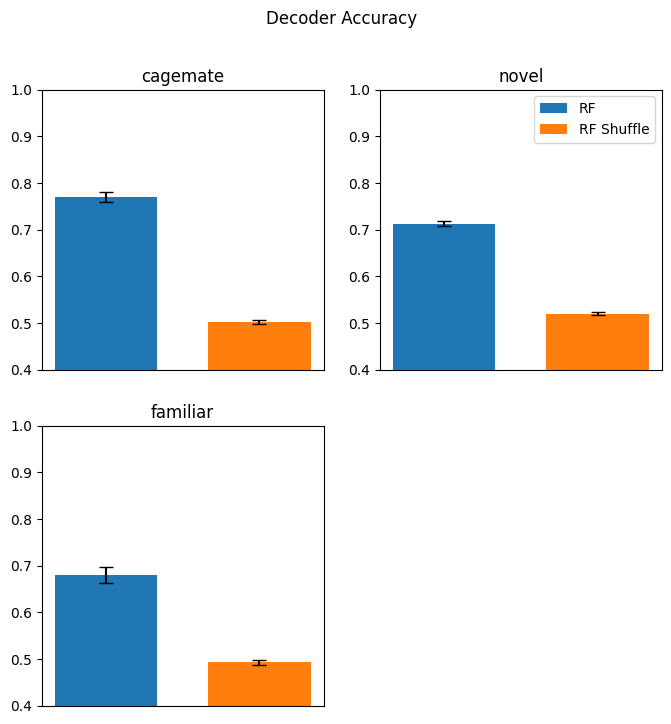

In [ ]:
agent_decoder_results.plot_average()

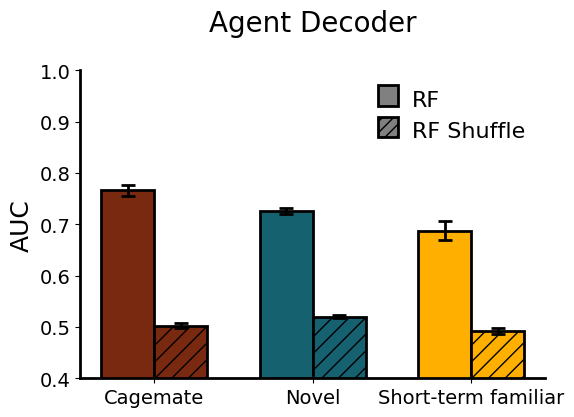

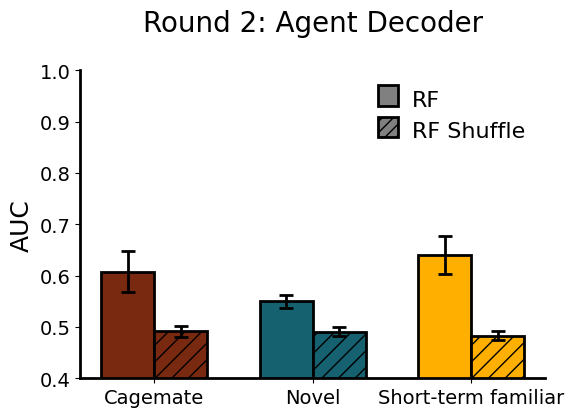

In [ ]:
plot_decoder_results(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     start = 0, stop = 3,
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))
              

## Location

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


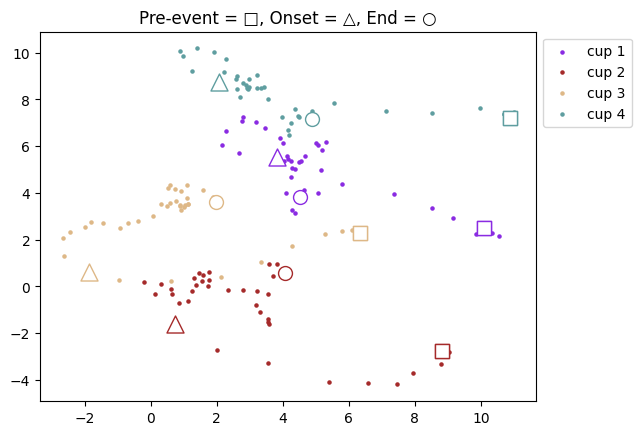

PCA Result with:
Events: cup 1, cup 2, cup 3, cup 4
Timebins per event: 40.0
Total neurons: 109
Number of recordings: 8
Number of Pcs needed to explain 90% of variance 14
Excluding 32_cups_p8_merged.rec with 4 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


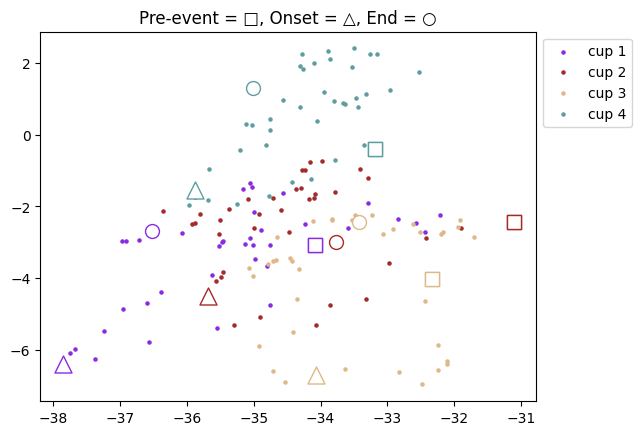

PCA Result with:
Events: cup 1, cup 2, cup 3, cup 4
Timebins per event: 40.0
Total neurons: 45
Number of recordings: 3
Number of Pcs needed to explain 90% of variance 10


In [ ]:
location_pca = population_analysis.avg_trajectories_pca(cups_collection, 3, 1, events = ['cup 1', 'cup 2', 'cup 3' , 'cup 4'], min_neurons = 5)
print(str(location_pca))


In [ ]:
plot_pca_results_2d(location_pca,
                    title = "Round 1: Location",
                    colors = ['#000000', '#404040', '#808080', '#BFBFBF'],
                    legend_spot = (0,1))
               
plot_pca_results_3d(location_pca,
                    title = "Location",
                    colors = ['#000000', '#404040', '#808080', '#BFBFBF'],
                   azim = 40, elev = 30)

In [ ]:
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
events = ['cup 1', 'cup 2','cup 3','cup 4']

location_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=14,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5)      


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 32_cups_p8_merged.rec with 4 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


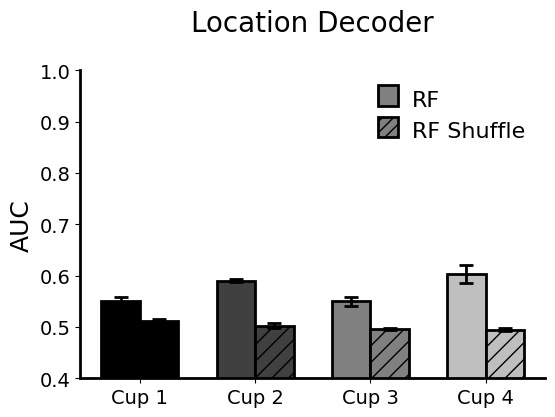

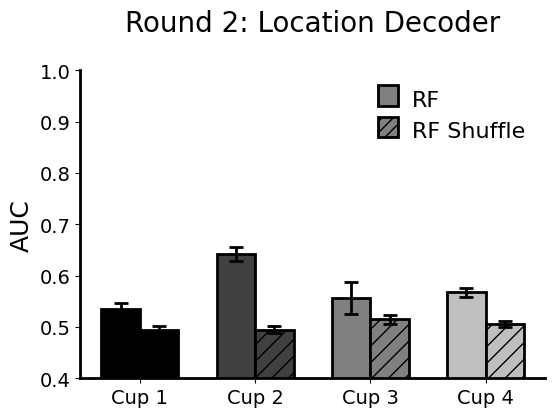

In [ ]:
plot_decoder_results(location_decoder_results, title = "Location Decoder", color_list = ['#000000', '#404040', '#808080', '#BFBFBF'],                                                       
                     start = 0, stop = 3,
                     legend_titles = ['Cup 1', 'Cup 2', 'Cup 3', 'Cup 4'], figsize = (6,4))


## Colors

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


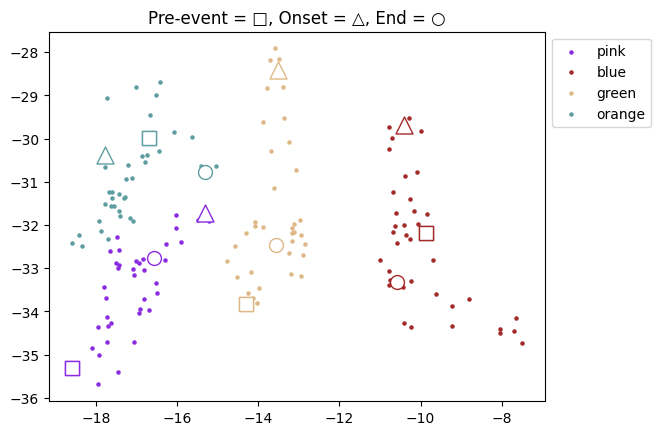

PCA Result with:
Events: pink, blue, green, orange
Timebins per event: 40.0
Total neurons: 109
Number of recordings: 8
Number of Pcs needed to explain 90% of variance 19
Excluding 32_cups_p8_merged.rec with 4 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


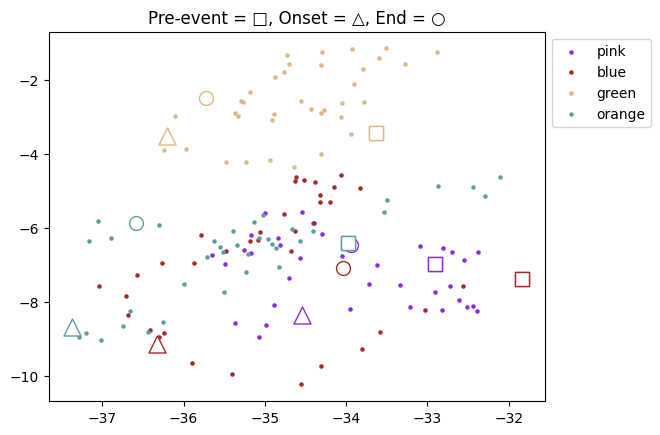

PCA Result with:
Events: pink, blue, green, orange
Timebins per event: 40.0
Total neurons: 45
Number of recordings: 3
Number of Pcs needed to explain 90% of variance 10


In [ ]:
color_pca = population_analysis.avg_trajectories_pca(cups_collection, 3, 1, events = ['pink', 'blue','green','orange'], min_neurons = 5)
print(str(color_pca))


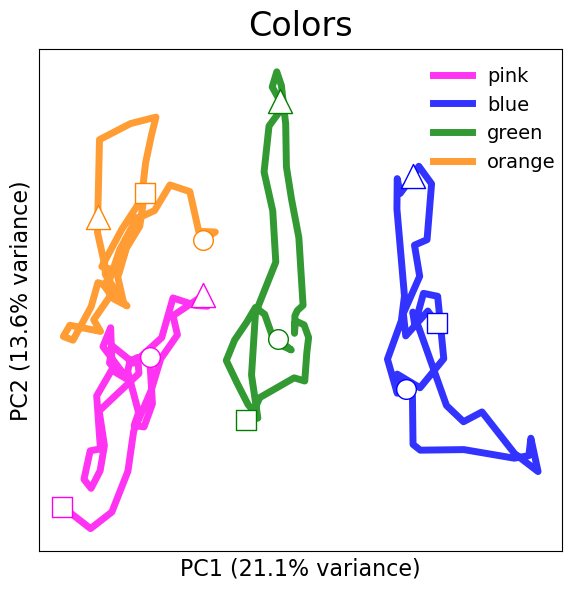

In [ ]:
plot_pca_results_2d(color_pca, title = 'Colors',colors = ['#ff00ef', 'blue', 'green', '#FF8300'], legend_spot = (.72,1) )

In [ ]:
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
events = ['pink', 'blue','green','orange']

color_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=19,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5)   
 

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Excluding 32_cups_p8_merged.rec with 4 neurons


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


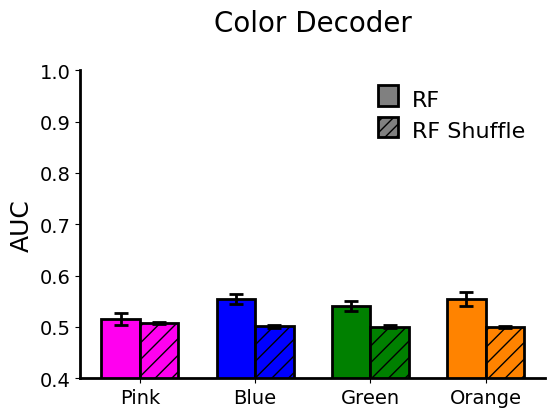

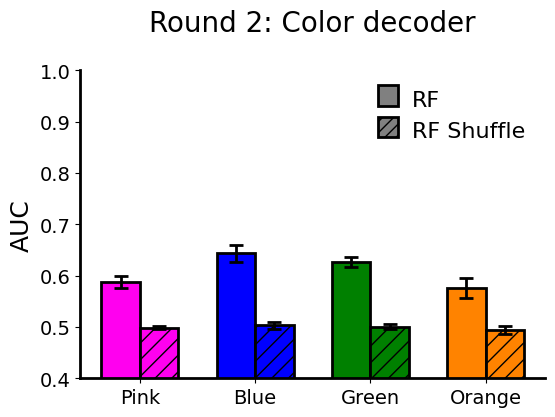

In [ ]:
plot_decoder_results(color_decoder_results, title = "Color Decoder", color_list = ['#ff00ef', 'blue', 'green', '#FF8300'],                                                       
                     start = 0, stop = 3,
                     legend_titles = ['Pink', 'Blue', 'Green', 'Orange'], figsize = (6,4))


## LOO Decoders

In [ ]:
import spike.spike_analysis.decoders as decoders

pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
events = ['cagemate','novel','familiar']

agent_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = True)      

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


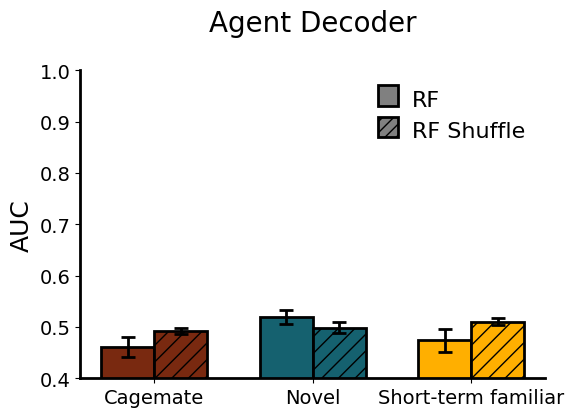

In [ ]:
plot_decoder_results(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     start = 0, stop = 3,
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))


In [ ]:
agent_decoder_results

Models ran with 8 folds
Events: ['cagemate', 'novel', 'familiar']
  cagemate: Model Results
Average AUC score: 0.479396370445696
Average AUC score for shuffled data: 0.49594886574836117
  novel: Model Results
Average AUC score: 0.5228928333175601
Average AUC score for shuffled data: 0.4997233769879966
  familiar: Model Results
Average AUC score: 0.4938630988525442
Average AUC score for shuffled data: 0.510985760418625

In [ ]:
from importlib import reload
reload(decoders)
pre_window = 5
event_length = 5
num_folds = 5
min_neurons = 5
agent_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="Linear")     

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


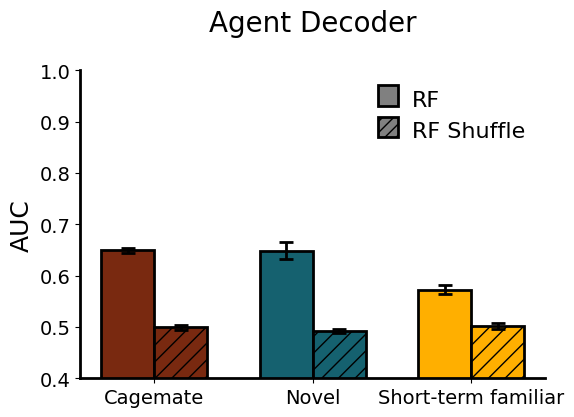

In [ ]:
plot_decoder_results(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     start = 0, stop = 3,
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))

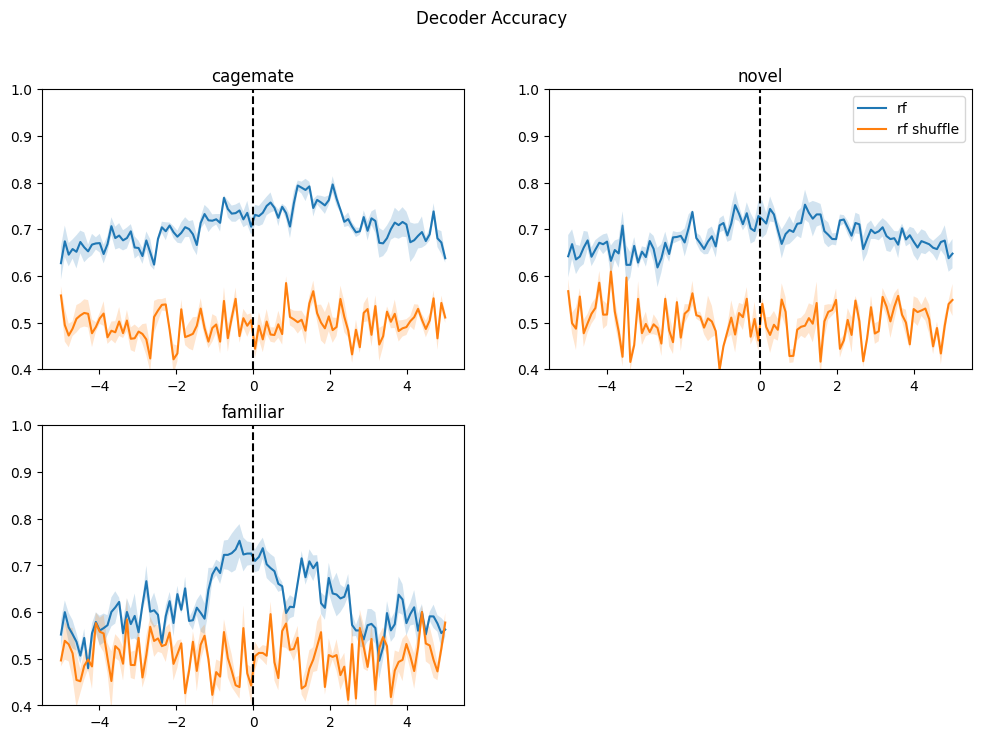

In [ ]:
agent_decoder_results.plot_across_time()

In [ ]:
from importlib import reload
reload(decoders)
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
agent_decoder_results = decoders.trial_decoder(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="RF",
                                         input = "full_trial") 

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [ ]:
from matplotlib.patches import Patch
def plot_decoder_results_flat(decoder, title, color_list, legend_titles, figsize ):
    bar_width = 0.2
    plt.figure(figsize=figsize)
    
    bar_position = 0  # Starting position for bars
    bar_centers = []  # Store center positions for labels
    j = 0
    
    # First, create bars without labels
    for key, results in decoder.results.items():
        
        total_event = decoder.event_length + decoder.post_window
        x = np.linspace(-decoder.pre_window, total_event, np.array(results.roc_auc).shape[0])

            
        rf_avg = np.mean(np.squeeze(results.roc_auc), axis=0)
        rf_sem = sem(np.squeeze(results.roc_auc), axis=0)
        rf_shuffle_avg = np.mean(np.squeeze(results.roc_auc_shuffle), axis=0)
        rf_shuffle_sem = sem(np.squeeze(results.roc_auc_shuffle), axis=0)
        
        # Plot bars without labels
        plt.bar(bar_position, rf_avg, bar_width, 
               yerr=rf_sem, capsize=5, color=color_list[j], 
               edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        plt.bar(bar_position + bar_width, rf_shuffle_avg, bar_width, 
               yerr=rf_shuffle_sem, capsize=5, color=color_list[j], 
               hatch='//', edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        
        # Store center position for this pair of bars
        bar_centers.append(bar_position + bar_width/2)
        
        bar_position += 0.6
        j += 1
    
    # Add centered labels under each pair of bars
    plt.xticks(bar_centers, legend_titles, fontsize=12)
    
    # Create custom legend for RF and RF Shuffle
    legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=2, label='RF'),
    Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='RF Shuffle')
    ]

    # Create the legend with modified properties
    leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
                    frameon=False, fontsize=16)

# Adjust the size of the patches in the legend
    for patch in leg.get_patches():
        patch.set_height(15)  # Adjust this value to change height
        patch.set_y(0)
        patch.set_width(15) 
        patch.set_x(20)
    
    plt.ylim(0.4, 1)
    plt.ylabel('AUC', fontsize=18)
    plt.xticks(fontsize = 14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.title(title, fontsize=20, y = 1.1)
    plt.yticks(fontsize=14)
    plt.show()


In [ ]:
agent_decoder_results.results['cagemate'].roc_auc

array([[0.8349359 , 0.80652261, 0.81232493, 0.82152861, 0.70812908]])

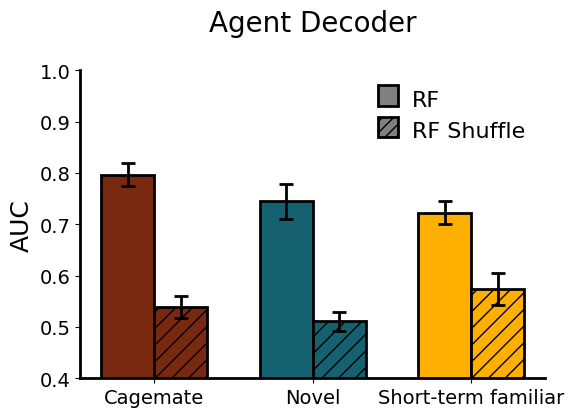

In [ ]:
plot_decoder_results_flat(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


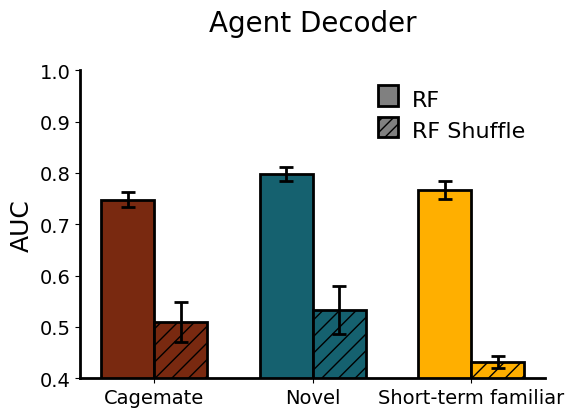

In [ ]:
from importlib import reload
reload(decoders)
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
agent_decoder_results = decoders.trial_decoder_within_subject_shuffle(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="RF",
                                         input = "full_trial",
                                         perm_type = "balanced") 
plot_decoder_results_flat(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


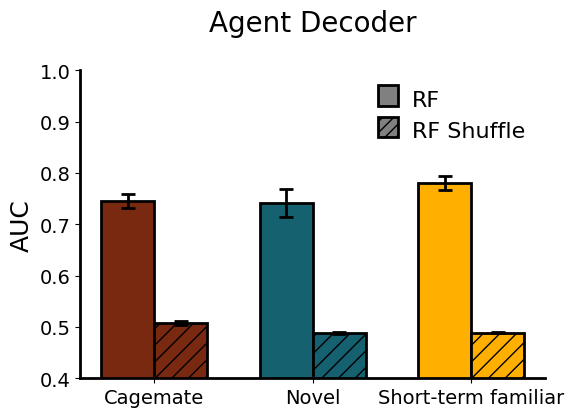

In [ ]:
from importlib import reload
reload(decoders)
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
agent_decoder_results = decoders.trial_decoder_within_subject_shuffle(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="RF",
                                         perm_type = "balanced") 
plot_decoder_results(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


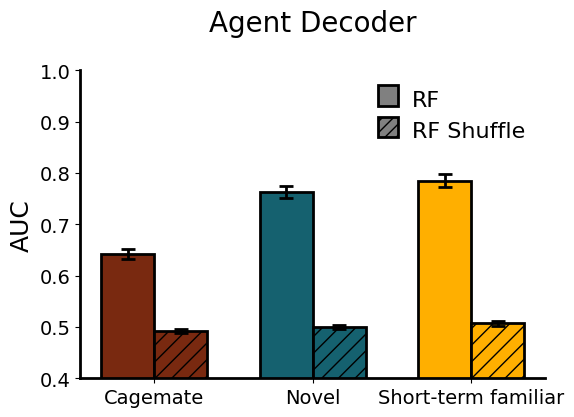

c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


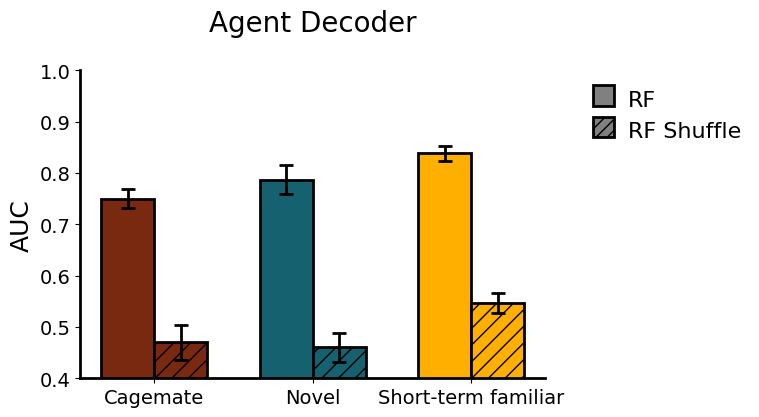

In [ ]:
from importlib import reload
reload(decoders)
pre_window = 1
event_length = 3
num_folds = 5
min_neurons = 5
agent_decoder_results = decoders.trial_decoder_within_subject_shuffle(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="Linear",
                                         perm_type = "balanced") 
plot_decoder_results(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))
agent_decoder_results = decoders.trial_decoder_within_subject_shuffle(cups_collection,
                                         num_fold=num_folds,
                                         no_PCs=10,
                                         events =events,
                                         event_length = event_length,
                                         pre_window = pre_window,
                                         min_neurons = 5,
                                         LOO = False,
                                         classifier_type="Linear",
                                         input="full_trial",
                                         perm_type = "balanced") 
plot_decoder_results_flat(agent_decoder_results, title = "Agent Decoder", color_list = [hex_2_rgb('#792910'),
                                                                                   hex_2_rgb('#15616F'),
                                                                                   (1.0, 0.6862745098039216, 0.0)],
                     legend_titles = ['Cagemate', 'Novel', 'Short-term familiar'], figsize = (6,4))
            

# Representational Geometry Analysis

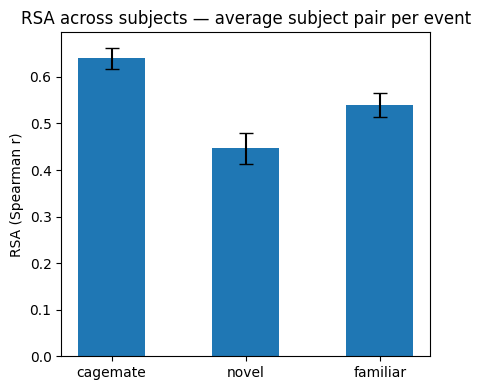

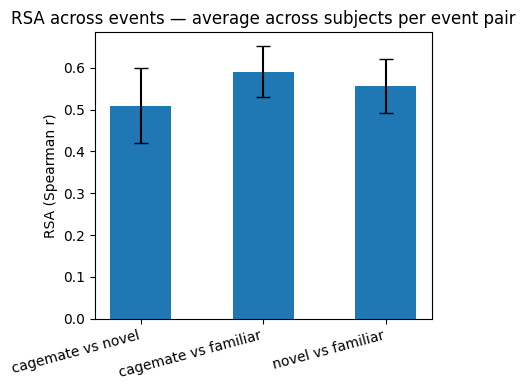

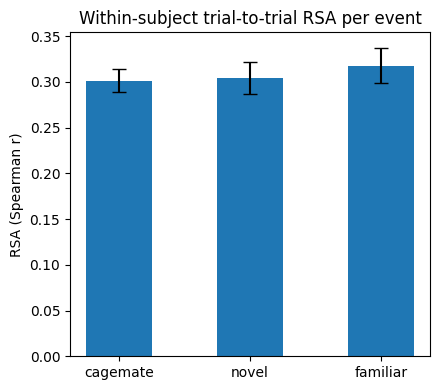

In [ ]:
reload(population_analysis)
across_subjects_rsa_results = population_analysis.rsa(cups_collection, events, 3, 1, across_subjects = True, plot = True)
across_events_rsa_results = population_analysis.rsa(cups_collection, events, 3, 1, across_events = True, plot = True)
across_trials_rsa_results = population_analysis.rsa(cups_collection, events, 3, 1, plot = True)

# dPCA

In [51]:
#X[n,t,s,d]

#currently PCA = [n, t*event] instead we could do [n, t, e] is the most basic which will not need any new labels. 
#we could add location for example [n, t, e, l]
def plot_explained_variance(explained_variance, n_components=10):
    import numpy as np
    import matplotlib.pyplot as plt

    # --- your explained variance dict looks something like this ---
    # explained_variance = {
    #     't':  [0.38, 0.11, 0.04, 0.02, ...],   # time
    #     'e':  [0.03, 0.01, 0.005, ...],          # event/stimulus
    #     'te': [0.09, 0.05, 0.02, ...],           # mixed interaction
    # }

    n_components = 10  # first 10 PCs to plot

    color_map = {
        't':  'mediumseagreen',   # time → green
        'e':  'steelblue',        # event → blue
        'te': 'darkgrey',         # mixed → grey
    }

    label_map = {
        't':  'Time',
        'e':  'Event',
        'te': 'Time × Event (mixed)',
    }

    # truncate or pad each list to n_components
    def get_values(lst, n):
        arr = np.array(lst[:n])          # take first n
        if len(arr) < n:                 # pad with zeros if shorter
            arr = np.pad(arr, (0, n - len(arr)))
        return arr

    x = np.arange(n_components)
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(10, 5))

    # plot order matters for stacking — draw bottom layers first
    # t at the base, then e on top, then te on top of that
    keys_ordered = ['t', 'e', 'te']
    bottoms = np.zeros(n_components)

    bars = {}
    for key in keys_ordered:
        if key not in explained_variance:
            continue
        vals = get_values(explained_variance[key], n_components)
        bars[key] = ax.bar(
            x,
            vals,
            bottom=bottoms,
            width=bar_width,
            color=color_map[key],
            label=label_map[key],
            edgecolor='white',
            linewidth=0.5,
        )
        bottoms += vals

    # formatting
    ax.set_xlabel('Component index', fontsize=12)
    ax.set_ylabel('Variance explained', fontsize=12)
    ax.set_title('dPCA — Variance Explained per Component', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f'PC{i+1}' for i in range(n_components)], fontsize=9)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_ylim(0, max(bottoms) * 1.15)   # 15% headroom above tallest bar
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

    # optional: add total variance label on top of each bar
    for i, total in enumerate(bottoms):
        ax.text(i, total + max(bottoms) * 0.01, f'{total:.3f}',
                ha='center', va='bottom', fontsize=7, color='dimgrey')

    plt.tight_layout()
    plt.show()

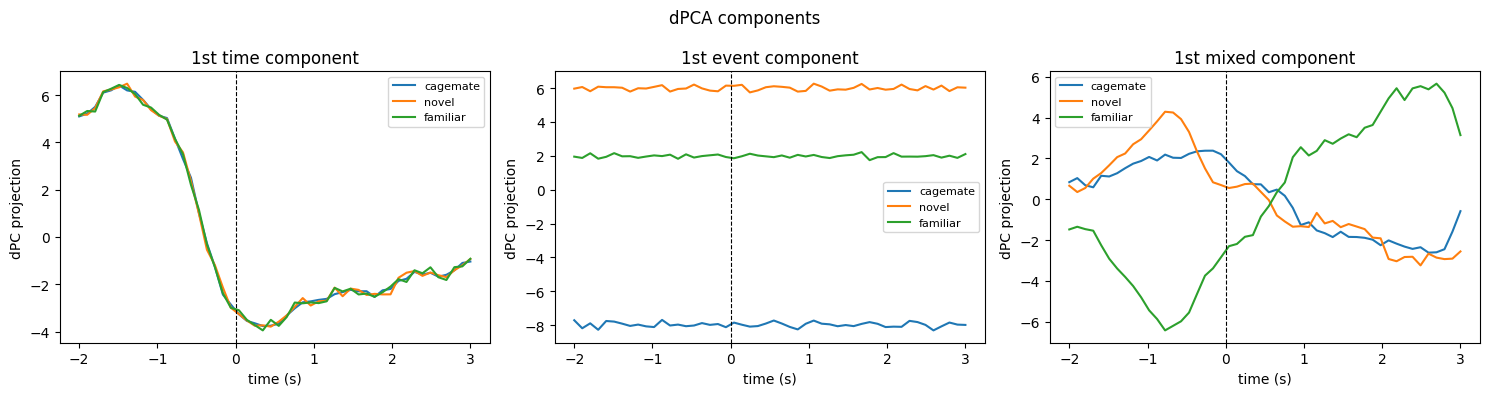

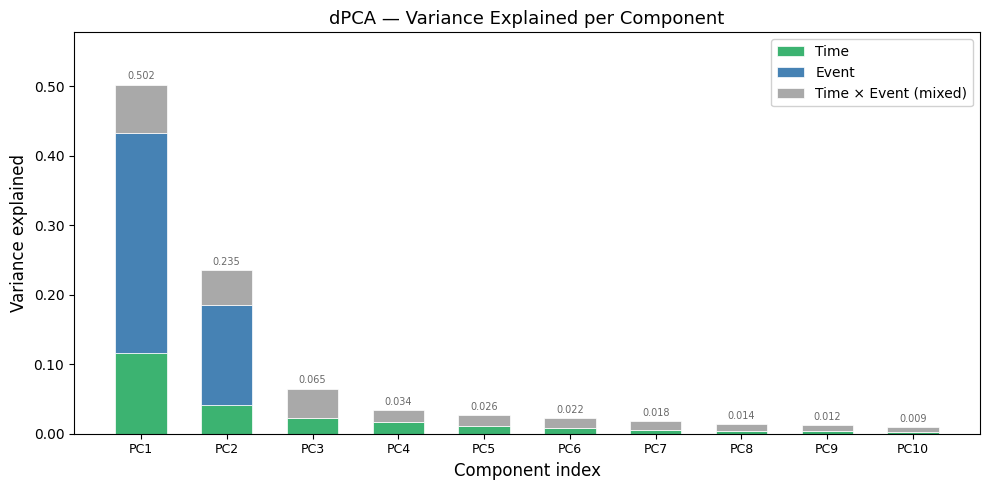

In [52]:

events = ['cagemate', 'novel', 'familiar']
Z, dpca, R, neuron_keys, event_list, _ = population_analysis.run_dpca(cups_collection,  3, 2, events = events, plot = True)
plot_explained_variance(dpca.explained_variance_ratio_, n_components=10)

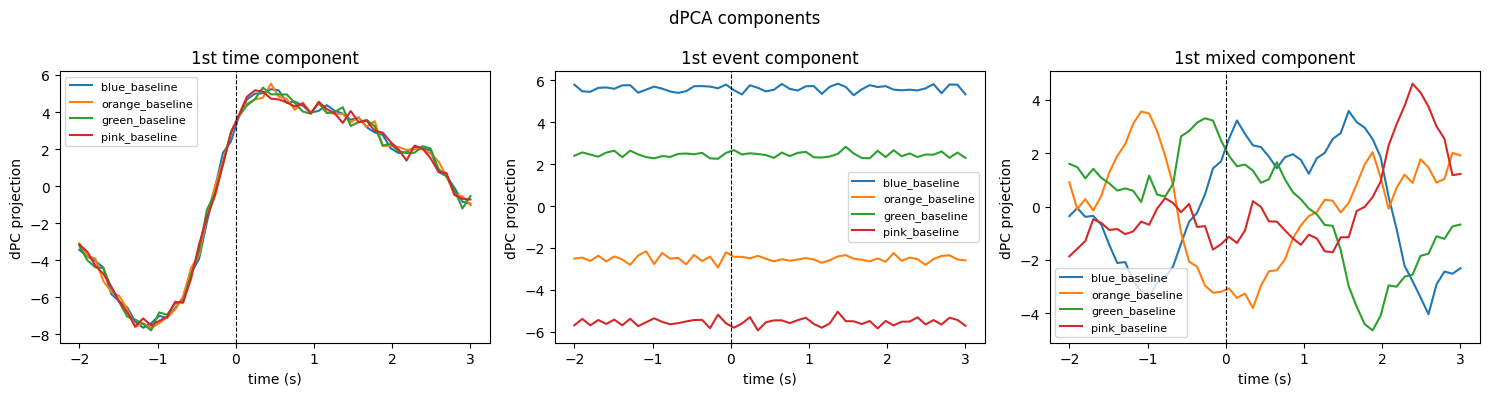

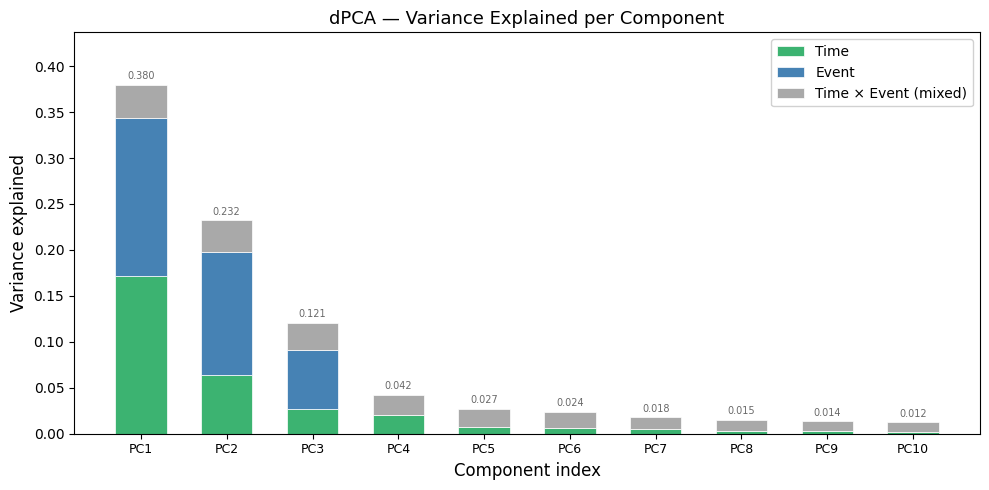

In [53]:
events = ['blue_baseline', 'orange_baseline', 'green_baseline', 'pink_baseline']
Z, dpca, R, neuron_keys, event_list, _ = population_analysis.run_dpca(cups_collection,  3, 2, events = events, plot = True)
plot_explained_variance(dpca.explained_variance_ratio_, n_components=10)



c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


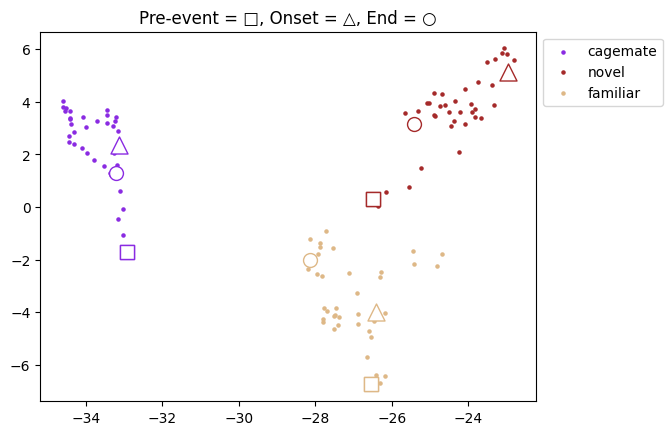

40
40 40
40 40
40 40


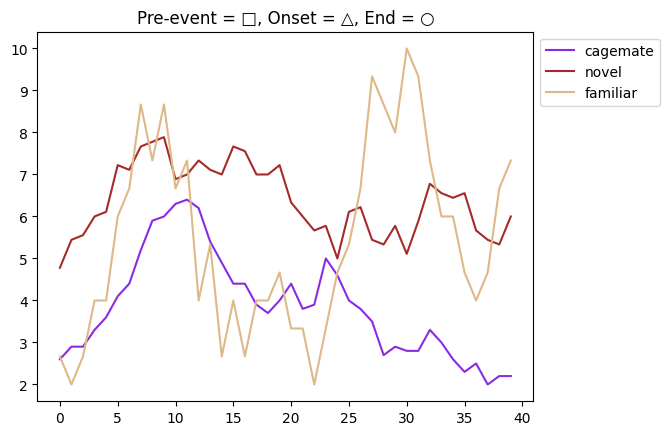

In [ ]:
event_length = 3
pre_window = 1
pca_result = population_analysis.avg_trajectories_pca(cups_collection, 3, 1, events = ['cagemate', 'novel','familiar'], min_neurons = 5)
df = pca_result.matrix_df 
conv_factor = 1000 / cups_collection.timebin

pca_matrix = pca_result.matrix_df.values  # converts DataFrame → numpy arrayprint(pca_matrix.shape)
post_window = 0
event_lengths = int((event_length + pre_window + post_window) * conv_factor)
print(event_lengths)
PCA_key = ['cagemate'] * event_lengths + ['novel'] * event_lengths + ['familiar'] * event_lengths

event_end = int((event_length + pre_window) * conv_factor)
pre_window = pre_window * conv_factor
post_window = post_window * conv_factor
colors_dict = plt.cm.colors.CSS4_COLORS
colors = list(colors_dict.values())
col_counter = 10
for i in range(0, len(PCA_key), event_lengths):
    event_label = PCA_key[i]
    onset = i if pre_window == 0 else int(i + pre_window - 1)
    end = int(i + event_end - 1)
    post = int(i + event_lengths - 1)
    print(len(np.arange(event_lengths)), len(pca_matrix[i : i + event_lengths, 0]))
    plt.plot(
        np.arange(event_lengths ),
        pca_matrix[i : i + event_lengths, 0],
        label=event_label,
        c=colors[col_counter],
    )
    col_counter += 1
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
post_win_text = ""
pre_win_text = ""
if post_window != 0:
    post_win_text = ", Post = ◇"
if pre_window != 0:
    pre_win_text = "Pre-event = □, "
title = pre_win_text + "Onset = △, End = ○" + post_win_text
plt.title(title)
plt.show()